<a href="https://colab.research.google.com/github/mohitkco/reference-free-deepfake/blob/main/ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cell 1: GPU check and Drive mount

run before every reload

In [ ]:
from google.colab import drive; drive.mount('/content/drive')
exec(open('/content/drive/MyDrive/refree/refree_lib.py').read())
FACES, DATA = load_all()
!nvidia-smi -L

Mounted at /content/drive
refree_lib loaded | device: cuda
loading prompts from items_meta_v2.pkl
train    4312 items | real 2158 fake 2154
val       837 items | real 420 fake 417
test     2096 items | real 420 fake 1676
unseen   1547 items | real 531 fake 1016
GPU 0: Tesla T4 (UUID: GPU-78fea3bd-1178-1ce5-3663-6cb7be3f230a)


In [ ]:
!nvidia-smi -L
from google.colab import drive
drive.mount('/content/drive')

/bin/bash: line 1: nvidia-smi: command not found


ValueError: Mountpoint must not already contain files

Cell 2: installs (dlib compiles from source, so this takes about 5–10 minutes)

In [ ]:
!apt-get -qq install -y cmake build-essential
%pip install -q dlib peft bitsandbytes accelerate transformers scikit-image opencv-python-headless
!wget -q http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bzip2 -df shape_predictor_68_face_landmarks.dat.bz2
!ls -lh shape_predictor_68_face_landmarks.dat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 26.3 MB/s eta 0:00:00
-rw-r--r-- 1 root root 96M Jul 24  2015 shape_predictor_68_face_landmarks.dat


dataset


In [ ]:
from google.colab import files
files.upload()   # choose download-FaceForensics.py

Saving download-FaceForensics.py to download-FaceForensics.py


{'download-FaceForensics.py': b'#!/usr/bin/env python\n""" Downloads FaceForensics++ and Deep Fake Detection public data release\nExample usage:\n    see -h or https://github.com/ondyari/FaceForensics\n"""\n# -*- coding: utf-8 -*-\nimport argparse\nimport os\nimport urllib\nimport urllib.request\nimport tempfile\nimport time\nimport sys\nimport json\nimport random\nfrom tqdm import tqdm\nfrom os.path import join\n\n\n# URLs and filenames\nFILELIST_URL = \'misc/filelist.json\'\nDEEPFEAKES_DETECTION_URL = \'misc/deepfake_detection_filenames.json\'\nDEEPFAKES_MODEL_NAMES = [\'decoder_A.h5\', \'decoder_B.h5\', \'encoder.h5\',]\n\n# Parameters\nDATASETS = {\n    \'original_youtube_videos\': \'misc/downloaded_youtube_videos.zip\',\n    \'original_youtube_videos_info\': \'misc/downloaded_youtube_videos_info.zip\',\n    \'original\': \'original_sequences/youtube\',\n    \'DeepFakeDetection_original\': \'original_sequences/actors\',\n    \'Deepfakes\': \'manipulated_sequences/Deepfakes\',\n    

In [ ]:
import urllib.request
SERVERS = {
    "EU":  "http://canis.vc.in.tum.de:8100/",
    "EU2": "http://kaldir.vc.in.tum.de/faceforensics/",
    "CA":  "http://falas.cmpt.sfu.ca:8100/",
}
for name, base in SERVERS.items():
    try:
        r = urllib.request.urlopen(base + "v3/misc/filelist.json", timeout=15)
        print(name, "OK", r.status)
    except Exception as e:
        print(name, "FAIL", repr(e)[:90])

EU FAIL URLError(ConnectionRefusedError(111, 'Connection refused'))
EU2 OK 200
CA FAIL URLError(TimeoutError('timed out'))


In [ ]:
!echo "" | python download-FaceForensics.py /content/FaceForensics++ -d original -c c23 -t videos -n 5 --server EU2
!find /content/FaceForensics++ -name "*.mp4" | head

By pressing any key to continue you confirm that you have agreed to the FaceForensics terms of use as described at:
http://kaldir.vc.in.tum.de/faceforensics/webpage/FaceForensics_TOS.pdf
***
Press any key to continue, or CTRL-C to exit.
Output path: /content/FaceForensics++/original_sequences/youtube/c23/videos
100% 5/5 [00:01<00:00,  3.64it/s]
/content/FaceForensics++/original_sequences/youtube/c23/videos/481.mp4
/content/FaceForensics++/original_sequences/youtube/c23/videos/469.mp4
/content/FaceForensics++/original_sequences/youtube/c23/videos/599.mp4
/content/FaceForensics++/original_sequences/youtube/c23/videos/183.mp4
/content/FaceForensics++/original_sequences/youtube/c23/videos/585.mp4


In [ ]:
!for d in original Deepfakes Face2Face FaceSwap NeuralTextures; do echo "" | python download-FaceForensics.py /content/FaceForensics++ -d $d -c c23 -t videos --server EU2; done
!du -sh /content/FaceForensics++

By pressing any key to continue you confirm that you have agreed to the FaceForensics terms of use as described at:
http://kaldir.vc.in.tum.de/faceforensics/webpage/FaceForensics_TOS.pdf
***
Press any key to continue, or CTRL-C to exit.
Output path: /content/FaceForensics++/original_sequences/youtube/c23/videos
100% 1000/1000 [04:35<00:00,  3.63it/s]
By pressing any key to continue you confirm that you have agreed to the FaceForensics terms of use as described at:
http://kaldir.vc.in.tum.de/faceforensics/webpage/FaceForensics_TOS.pdf
***
Press any key to continue, or CTRL-C to exit.
Output path: /content/FaceForensics++/manipulated_sequences/Deepfakes/c23/videos
100% 1000/1000 [04:39<00:00,  3.58it/s]
By pressing any key to continue you confirm that you have agreed to the FaceForensics terms of use as described at:
http://kaldir.vc.in.tum.de/faceforensics/webpage/FaceForensics_TOS.pdf
***
Press any key to continue, or CTRL-C to exit.
Output path: /content/FaceForensics++/manipulated_se

Celeb-DF-v2

In [ ]:
ZIP = "/content/drive/MyDrive/Celeb-DF-v2.zip"   # <- edit to your zip's path
!mkdir -p /content/Celeb-DF-v2
!unzip -q "{ZIP}" -d /content/Celeb-DF-v2
!find /content/Celeb-DF-v2 -maxdepth 2 | head -20

/content/Celeb-DF-v2
/content/Celeb-DF-v2/List_of_testing_videos.txt
/content/Celeb-DF-v2/Celeb-synthesis
/content/Celeb-DF-v2/Celeb-synthesis/id17_id26_0005.mp4
/content/Celeb-DF-v2/Celeb-synthesis/id30_id29_0003.mp4
/content/Celeb-DF-v2/Celeb-synthesis/id40_id47_0007.mp4
/content/Celeb-DF-v2/Celeb-synthesis/id17_id16_0001.mp4
/content/Celeb-DF-v2/Celeb-synthesis/id55_id51_0009.mp4
/content/Celeb-DF-v2/Celeb-synthesis/id9_id6_0004.mp4
/content/Celeb-DF-v2/Celeb-synthesis/id1_id20_0003.mp4
/content/Celeb-DF-v2/Celeb-synthesis/id24_id22_0009.mp4
/content/Celeb-DF-v2/Celeb-synthesis/id34_id31_0005.mp4
/content/Celeb-DF-v2/Celeb-synthesis/id49_id56_0002.mp4
/content/Celeb-DF-v2/Celeb-synthesis/id35_id9_0003.mp4
/content/Celeb-DF-v2/Celeb-synthesis/id52_id58_0009.mp4
/content/Celeb-DF-v2/Celeb-synthesis/id6_id21_0005.mp4
/content/Celeb-DF-v2/Celeb-synthesis/id22_id21_0006.mp4
/content/Celeb-DF-v2/Celeb-synthesis/id58_id56_0007.mp4
/content/Celeb-DF-v2/Celeb-synthesis/id20_id3_0001.mp4
/con

Cell 3: point to your data (edit the first two paths)

In [ ]:
import shutil, os
DRIVE_FFPP   = "/content/drive/MyDrive/FaceForensics++"   # <- edit
DRIVE_CELEB  = "/content/drive/MyDrive/Celeb-DF-v2"       # <- edit

# Reading many mp4s straight from Drive is slow. If the data is a .zip, unzip it to /content:
# !unzip -q "/content/drive/MyDrive/FF++.zip" -d /content/FaceForensics++
# Otherwise, copy the folders to local disk:
# shutil.copytree(DRIVE_FFPP, "/content/FaceForensics++")

FFPP_ROOT, CELEBDF_ROOT = "/content/FaceForensics++", "/content/Celeb-DF-v2"

Cell 4: verify the dataset layout (this matches what build_manifest_ffpp and build_manifest_celebdf expect)

In [ ]:
from pathlib import Path
def n(p, pat="*.mp4"):
    p = Path(p); return len(list(p.glob(pat))) if p.exists() else "MISSING"

FF = Path(FFPP_ROOT)
print("FF++ real      :", n(FF/"original_sequences/youtube/c23/videos"))
for m in ["Deepfakes","Face2Face","FaceSwap","NeuralTextures"]:
    print(f"FF++ {m:15s}:", n(FF/f"manipulated_sequences/{m}/c23/videos"))
CD = Path(CELEBDF_ROOT)
for s in ["Celeb-real","YouTube-real","Celeb-synthesis"]:
    print(f"Celeb-DF {s:16s}:", n(CD/s))

# if anything says MISSING, show what is actually there:
!find {FFPP_ROOT} -maxdepth 3 -type d | head -30
!find {CELEBDF_ROOT} -maxdepth 2 | head -15

FF++ real      : 1000
FF++ Deepfakes      : 1000
FF++ Face2Face      : 1000
FF++ FaceSwap       : 1000
FF++ NeuralTextures : 1000
Celeb-DF Celeb-real      : 590
Celeb-DF YouTube-real    : 300
Celeb-DF Celeb-synthesis : 5639
/content/FaceForensics++
/content/FaceForensics++/manipulated_sequences
/content/FaceForensics++/manipulated_sequences/FaceSwap
/content/FaceForensics++/manipulated_sequences/FaceSwap/c23
/content/FaceForensics++/manipulated_sequences/Deepfakes
/content/FaceForensics++/manipulated_sequences/Deepfakes/c23
/content/FaceForensics++/manipulated_sequences/Face2Face
/content/FaceForensics++/manipulated_sequences/Face2Face/c23
/content/FaceForensics++/manipulated_sequences/NeuralTextures
/content/FaceForensics++/manipulated_sequences/NeuralTextures/c23
/content/FaceForensics++/original_sequences
/content/FaceForensics++/original_sequences/youtube
/content/FaceForensics++/original_sequences/youtube/c23
/content/Celeb-DF-v2
/content/Celeb-DF-v2/List_of_testing_videos.txt
/co

Cell 1: imports, config and helper functions

Run this and paste only what it prints at the bottom.

In [ ]:
import os, json, math, time, random, warnings, urllib.request
from pathlib import Path
from types import SimpleNamespace
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

cfg = SimpleNamespace(
    SEED=42, IMG=224, FRAMES_PER_VIDEO=3,
    FFPP_ROOT="/content/FaceForensics++", FFPP_COMPRESSION="c23",
    CELEBDF_ROOT="/content/Celeb-DF-v2",
    DLIB_PREDICTOR="/content/shape_predictor_68_face_landmarks.dat")
S = cfg.IMG
random.seed(cfg.SEED); np.random.seed(cfg.SEED)

# ---- canonical 68-point template (iBUG ordering) ----
def make_template_68():
    pts = []
    t = np.linspace(0, np.pi, 17)
    pts += list(zip(112 - 80*np.cos(t), 85 + 110*np.sin(t)))                    # jaw 0-16
    u = np.linspace(0, np.pi, 5)
    pts += list(zip(np.linspace(48, 98, 5), 62 - 8*np.sin(u)))                  # right brow
    pts += list(zip(np.linspace(126, 176, 5), 62 - 8*np.sin(u)))                # left brow
    pts += [(112, 75), (112, 90), (112, 105), (112, 118)]                       # nose bridge
    pts += list(zip(np.linspace(94, 130, 5), [130, 134, 136, 134, 130]))        # nose base
    ang = np.deg2rad([180, 125, 55, 0, -55, -125])
    for cx in (76, 148):                                                        # eyes
        pts += list(zip(cx + 17*np.cos(ang), 86 - 7*np.sin(ang)))
    a = np.deg2rad([180, 150, 120, 90, 60, 30, 0, -30, -60, -90, -120, -150])
    pts += list(zip(112 + 32*np.cos(a), 165 - 14*np.sin(a)))                    # mouth outer
    a = np.deg2rad([180, 120, 90, 60, 0, -60, -90, -120])
    pts += list(zip(112 + 20*np.cos(a), 165 - 5*np.sin(a)))                     # mouth inner
    return np.array(pts, dtype=np.float32)
TEMPLATE_68 = make_template_68(); assert TEMPLATE_68.shape == (68, 2)

# ---- frame sampling, dlib, alignment ----
STABLE_PTS = [36, 39, 42, 45, 30, 48, 54]

def sample_frame_indices(n_frames, k=cfg.FRAMES_PER_VIDEO):
    return ((np.arange(k) + 0.5) * n_frames / k).astype(int)

def read_frames(video_path, k=cfg.FRAMES_PER_VIDEO):
    cap = cv2.VideoCapture(str(video_path))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); frames = []
    for idx in sample_frame_indices(max(n, k), k):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, fr = cap.read()
        if ok: frames.append(fr)
    cap.release(); return frames

_dlib = {}
def detect_landmarks(frame_bgr):
    if "det" not in _dlib:
        import dlib
        _dlib["det"] = dlib.get_frontal_face_detector()
        _dlib["sp"] = dlib.shape_predictor(cfg.DLIB_PREDICTOR)
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    faces = _dlib["det"](gray, 1)
    if not faces: return None
    f = max(faces, key=lambda r: r.width() * r.height())
    shp = _dlib["sp"](gray, f)
    return np.array([[p.x, p.y] for p in shp.parts()], dtype=np.float32)

def align_face(frame_bgr, lm, size=S):
    M, _ = cv2.estimateAffinePartial2D(lm[STABLE_PTS], TEMPLATE_68[STABLE_PTS], method=cv2.LMEDS)
    crop = cv2.warpAffine(frame_bgr, M, (size, size), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REFLECT)
    return crop, (lm @ M[:, :2].T + M[:, 2]).astype(np.float32)

# ---- manifests ----
FFPP_METHODS = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]
def build_manifest_ffpp(root=cfg.FFPP_ROOT, comp=cfg.FFPP_COMPRESSION):
    rows = []
    for p in sorted(Path(root, "original_sequences", "youtube", comp, "videos").glob("*.mp4")):
        rows.append(dict(path=str(p), label=0, method="real", video=p.stem, dataset="ffpp"))
    for m in FFPP_METHODS:
        for p in sorted(Path(root, "manipulated_sequences", m, comp, "videos").glob("*.mp4")):
            rows.append(dict(path=str(p), label=1, method=m, video=f"{m}/{p.stem}", dataset="ffpp"))
    return pd.DataFrame(rows)

def build_manifest_celebdf(root=cfg.CELEBDF_ROOT):
    rows = []
    for sub, lab in [("Celeb-real", 0), ("YouTube-real", 0), ("Celeb-synthesis", 1)]:
        for p in sorted(Path(root, sub).glob("*.mp4")):
            rows.append(dict(path=str(p), label=lab, method=sub, video=f"{sub}/{p.stem}", dataset="celebdf"))
    return pd.DataFrame(rows)

# ---- sanity checks ----
import dlib
print("dlib", dlib.__version__, "| predictor present:", os.path.exists(cfg.DLIB_PREDICTOR))
print("FF++ videos:", len(build_manifest_ffpp()), "| Celeb-DF videos:", len(build_manifest_celebdf()))

dlib 20.0.1 | predictor present: False
FF++ videos: 0 | Celeb-DF videos: 0


Cell 2: official splits and the video selection

Run this after Cell 1 succeeds. The first run needs internet access to fetch the FF++ split lists, and it falls back to a seeded random split if that fails.

In [ ]:
SPLIT_URL = "https://raw.githubusercontent.com/ondyari/FaceForensics/master/dataset/splits/{}.json"
def load_split_ids():
    try:
        out = {}
        for s in ("train", "val", "test"):
            pairs = json.loads(urllib.request.urlopen(SPLIT_URL.format(s), timeout=30).read())
            out[s] = {i for p in pairs for i in p}
        print("official FF++ splits (ids):", {k: len(v) for k, v in out.items()})
    except Exception as e:
        print("could not fetch official splits:", repr(e)[:80], "-> seeded random split by id")
        ids = sorted(p.stem for p in Path(cfg.FFPP_ROOT, "original_sequences/youtube", cfg.FFPP_COMPRESSION, "videos").glob("*.mp4"))
        random.Random(cfg.SEED).shuffle(ids)
        out = {"train": set(ids[:720]), "val": set(ids[720:860]), "test": set(ids[860:])}
    return out

def ffpp_split_manifest():
    ids, man = load_split_ids(), build_manifest_ffpp()
    first = man.video.str.split("/").str[-1].str.split("_").str[0]      # "071_054" -> "071"
    man["split"] = first.map(lambda i: next((s for s in ("train", "val", "test") if i in ids[s]), None))
    return man

K = dict(train=180, val=35, test=140)           # fake videos per manipulation method (all real videos are kept)
def pick(man, split, k):
    m = man[man.split == split]
    fakes = [g.sample(min(k, len(g)), random_state=cfg.SEED) for _, g in m[m.label == 1].groupby("method")]
    return pd.concat([m[m.label == 0]] + fakes).reset_index(drop=True)

def celeb_test_manifest():                      # official test list; label comes from the FOLDER name
    man = build_manifest_celebdf()
    keep = {l.split()[1].strip() for l in open(Path(cfg.CELEBDF_ROOT, "List_of_testing_videos.txt")) if l.strip()}
    rel = man.path.map(lambda p: str(Path(p).relative_to(cfg.CELEBDF_ROOT)))
    return man[rel.isin(keep)].reset_index(drop=True)

man_ff = ffpp_split_manifest()
print("videos with no split assigned:", int(man_ff.split.isna().sum()))
SEL = {s: pick(man_ff, s, K[s]) for s in ("train", "val", "test")}
SEL["unseen"] = celeb_test_manifest()
for s, m in SEL.items():
    print(f"{s:7s} {len(m):5d} videos ->", m.groupby("method").size().to_dict())

official FF++ splits (ids): {'train': 720, 'val': 140, 'test': 140}


AttributeError: 'DataFrame' object has no attribute 'video'

Cell 3: smoke test on 6 faces

This tests video decoding, face detection, landmarks and alignment on 3 FF++ and 3 Celeb-DF videos before the long job. Detection runs on a downscaled copy of each frame, because dlib is slow on 1080p frames.

In [ ]:
DET_MAX = 640
def detect_landmarks_fast(frame):
    h, w = frame.shape[:2]; s = min(1.0, DET_MAX / max(h, w))
    small = cv2.resize(frame, (int(w * s), int(h * s)), interpolation=cv2.INTER_AREA) if s < 1 else frame
    lm = detect_landmarks(small)
    return None if lm is None else (lm / s).astype(np.float32)

t0 = time.time(); shown = []
sample = pd.concat([SEL["train"].sample(3, random_state=1), SEL["unseen"].sample(3, random_state=1)])
for _, r in sample.iterrows():
    frs = read_frames(r.path)
    if not frs: print("COULD NOT DECODE:", r.video); continue
    lm = detect_landmarks_fast(frs[0])
    if lm is None: print("NO FACE:", r.video); continue
    im, lm_al = align_face(frs[0], lm); shown.append((im, lm_al, r.method))
print(f"{len(shown)}/6 faces in {time.time()-t0:.1f}s")

fig, ax = plt.subplots(1, max(len(shown), 2), figsize=(3 * max(len(shown), 2), 3.2))
for a_, (im, l, t) in zip(np.atleast_1d(ax), shown):
    a_.imshow(im[..., ::-1]); a_.scatter(*l.T, s=3, c="lime"); a_.set_title(t, fontsize=8); a_.axis("off")
plt.show()

NameError: name 'SEL' is not defined

Cell 4: extraction (resumable, saves to Drive)

It processes the splits in this order: val, test, unseen, train. The small split runs first, so you see timing quickly and can stop early if something is wrong. It writes one file per 100 videos to Drive. If Colab disconnects, re-run the same cell and it skips the shards that are already finished.

In [ ]:
CACHE = Path("/content/drive/MyDrive/refree_cache"); CACHE.mkdir(parents=True, exist_ok=True)

def extract(man, name, shard=100):
    n_sh = math.ceil(len(man) / shard)
    for si in range(n_sh):
        f = CACHE / f"{name}_{si:03d}.npz"
        if f.exists(): continue
        imgs, lms, rows, t0 = [], [], [], time.time()
        for _, r in man.iloc[si * shard:(si + 1) * shard].iterrows():
            for fr in read_frames(r.path):
                lm = detect_landmarks_fast(fr)
                if lm is None: continue
                im, lm_al = align_face(fr, lm)
                imgs.append(im); lms.append(lm_al); rows.append((int(r.label), r.method, r.video))
        np.savez(f,
                 imgs=np.stack(imgs) if imgs else np.zeros((0, S, S, 3), np.uint8),
                 lms=np.stack(lms) if lms else np.zeros((0, 68, 2), np.float32),
                 label=np.array([x[0] for x in rows], dtype=np.int64),
                 method=np.array([x[1] for x in rows]),
                 video=np.array([x[2] for x in rows]))
        print(f"{name}: shard {si+1}/{n_sh} done in {time.time()-t0:.0f}s ({len(imgs)} faces)", flush=True)

for s in ("val", "test", "unseen", "train"):
    extract(SEL[s], s)
print("ALL DONE")

val: shard 1/3 done in 196s (300 faces)
val: shard 2/3 done in 196s (297 faces)
val: shard 3/3 done in 150s (240 faces)
test: shard 1/7 done in 201s (300 faces)
test: shard 2/7 done in 207s (300 faces)
test: shard 3/7 done in 227s (299 faces)
test: shard 4/7 done in 202s (299 faces)
test: shard 5/7 done in 205s (298 faces)
test: shard 6/7 done in 207s (300 faces)
test: shard 7/7 done in 207s (300 faces)
unseen: shard 1/6 done in 52s (299 faces)
unseen: shard 2/6 done in 57s (295 faces)
unseen: shard 3/6 done in 54s (300 faces)
unseen: shard 4/6 done in 50s (300 faces)
unseen: shard 5/6 done in 51s (299 faces)
unseen: shard 6/6 done in 10s (54 faces)
train: shard 1/15 done in 199s (300 faces)
train: shard 2/15 done in 183s (300 faces)
train: shard 3/15 done in 201s (300 faces)
train: shard 4/15 done in 226s (299 faces)
train: shard 5/15 done in 226s (299 faces)
train: shard 6/15 done in 227s (300 faces)
train: shard 7/15 done in 241s (300 faces)
train: shard 8/15 done in 221s (299 faces

Cell 5: load the cache (run after ALL DONE)

In [ ]:
CACHE = Path("/content/drive/MyDrive/refree_cache"); CACHE.mkdir(parents=True, exist_ok=True)

def load_faces(name):
    out = []
    for f in sorted(CACHE.glob(f"{name}_*.npz")):
        z = np.load(f); imgs, lms, lab, met, vid = z["imgs"], z["lms"], z["label"], z["method"], z["video"]
        out += [dict(img=imgs[i], lm=lms[i], label=int(lab[i]), method=str(met[i]), video=str(vid[i])) for i in range(len(lab))]
    return out

FACES = {s: load_faces(s) for s in ("train", "val", "test", "unseen")}
for s, v in FACES.items():
    print(s, len(v), "faces | real:", sum(x["label"] == 0 for x in v), "fake:", sum(x["label"] == 1 for x in v))

train 0 faces | real: 0 fake: 0
val 0 faces | real: 0 fake: 0
test 0 faces | real: 0 fake: 0
unseen 0 faces | real: 0 fake: 0


Cell 6: priors, autoencoder, fusion (definitions only, runs in seconds)

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(cfg.SEED)
print("device:", DEVICE)

# ---------------- region masks (notebook §1) ----------------
REGION_NAMES = ["left eye", "right eye", "nose", "mouth", "face boundary"]
def region_masks(lm, size=S):
    lm = np.asarray(lm)
    def poly(idx, grow=0):
        m = np.zeros((size, size), np.uint8)
        cv2.fillConvexPoly(m, cv2.convexHull(lm[idx].astype(np.int32)), 1)
        if grow:
            k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (grow, grow))
            m = cv2.dilate(m, k)
        return m.astype(bool)
    hull = poly(list(range(0, 27)))
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (17, 17))
    ring = cv2.dilate(hull.astype(np.uint8), k).astype(bool) & ~cv2.erode(hull.astype(np.uint8), k).astype(bool)
    return {"left eye": poly(list(range(42, 48)), 11), "right eye": poly(list(range(36, 42)), 11),
            "nose": poly(list(range(27, 36)), 11), "mouth": poly(list(range(48, 68)), 11),
            "face boundary": ring, "face": hull}

# ---------------- reference-free priors (notebook §3) ----------------
SRM_KERNELS = [
    np.array([[0, 0, 0, 0, 0], [0, -1, 2, -1, 0], [0, 2, -4, 2, 0], [0, -1, 2, -1, 0], [0, 0, 0, 0, 0]], np.float32) / 4,
    np.array([[-1, 2, -2, 2, -1], [2, -6, 8, -6, 2], [-2, 8, -12, 8, -2], [2, -6, 8, -6, 2], [-1, 2, -2, 2, -1]], np.float32) / 12,
    np.array([[0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 1, -2, 1, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]], np.float32) / 2,
]
def to_gray(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)
def srm_residuals(gray):
    return [cv2.filter2D(gray, cv2.CV_32F, k, borderType=cv2.BORDER_REFLECT) for k in SRM_KERNELS]
def srm_log_energy(gray, win=13):
    e = sum(cv2.boxFilter(r * r, -1, (win, win), borderType=cv2.BORDER_REFLECT) for r in srm_residuals(gray)) / len(SRM_KERNELS)
    return np.log(e + 1e-3)

_HANN = np.outer(np.hanning(32), np.hanning(32)).astype(np.float32)
_FREQ = np.sqrt(np.fft.fftfreq(32)[:, None] ** 2 + np.fft.fftfreq(32)[None, :] ** 2)
def fft_hf_map(gray, win=32, stride=8, r0=0.25):
    from numpy.lib.stride_tricks import sliding_window_view
    H, W = gray.shape
    gp = np.pad(gray, win // 2, mode="reflect")
    w = sliding_window_view(gp, (win, win))[::stride, ::stride]
    w = (w - w.mean((-1, -2), keepdims=True)) * _HANN
    P = np.abs(np.fft.fft2(w)) ** 2
    ratio = np.log(P[..., _FREQ > r0].sum(-1) / (P.sum((-1, -2)) + 1e-6) + 1e-6).astype(np.float32)
    return cv2.resize(ratio, (W, H), interpolation=cv2.INTER_CUBIC)

def midline_x(lm):
    return float(np.asarray(lm)[[27, 28, 29, 30, 33, 51, 57, 8], 0].mean())
def mirror(x, xm):
    M = np.float32([[-1, 0, 2 * xm], [0, 1, 0]])
    return cv2.warpAffine(x, M, (x.shape[1], x.shape[0]), borderMode=cv2.BORDER_REFLECT)
def symmetry_maps(gray, logE, lm):
    xm = midline_x(lm)
    hp = gray - cv2.GaussianBlur(gray, (0, 0), 4)
    d_tex = cv2.GaussianBlur(np.abs(hp - mirror(hp, xm)), (0, 0), 3)
    d_res = cv2.GaussianBlur(np.abs(logE - mirror(logE, xm)), (0, 0), 3)
    return d_tex, d_res

PRIOR_NAMES = ["srm", "fft", "sym_tex", "sym_res", "ae"]
ONE_SIDED = {"sym_tex", "sym_res", "ae"}
def raw_maps(img_bgr, lm):
    g = to_gray(img_bgr); logE = srm_log_energy(g)
    d_tex, d_res = symmetry_maps(g, logE, lm)
    return {"srm": logE, "fft": fft_hf_map(g), "sym_tex": d_tex, "sym_res": d_res}

def radial_spectrum(img_bgr, nb=8):
    g = to_gray(img_bgr); g = (g - g.mean()) * np.outer(np.hanning(S), np.hanning(S))
    P = np.fft.fftshift(np.abs(np.fft.fft2(g)) ** 2)
    yy, xx = np.indices(P.shape); r = np.hypot(yy - S / 2, xx - S / 2) / (S / 2)
    edges = np.linspace(0, 1, nb + 1)
    return np.array([np.log(P[(r >= edges[i]) & (r < edges[i + 1])].mean() + 1e-6) for i in range(nb)], np.float32)

# ---------------- pseudo-reference autoencoder (notebook §4) ----------------
class FaceAE(nn.Module):
    def __init__(self, c=(16, 32, 64), z=8):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(3, c[0], 4, 2, 1), nn.ReLU(True), nn.Conv2d(c[0], c[1], 4, 2, 1), nn.ReLU(True),
            nn.Conv2d(c[1], c[2], 4, 2, 1), nn.ReLU(True), nn.Conv2d(c[2], z, 1))
        self.dec = nn.Sequential(
            nn.Conv2d(z, c[2], 1), nn.ReLU(True), nn.ConvTranspose2d(c[2], c[1], 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(c[1], c[0], 4, 2, 1), nn.ReLU(True), nn.ConvTranspose2d(c[0], 3, 4, 2, 1), nn.Sigmoid())
    def forward(self, x):
        return self.dec(self.enc(x))

def img_to_tensor01(imgs):
    a = np.stack([im[..., ::-1] for im in imgs]).astype(np.float32) / 255.0
    return torch.from_numpy(a).permute(0, 3, 1, 2).contiguous()

def train_ae(real_imgs, epochs=15, bs=16, lr=2e-3):
    ae = FaceAE().to(DEVICE)
    opt = torch.optim.Adam(ae.parameters(), lr=lr)
    X = torch.from_numpy(np.stack([im[..., ::-1] for im in real_imgs])).permute(0, 3, 1, 2).contiguous()   # uint8, saves RAM
    for ep in range(epochs):
        perm = torch.randperm(len(X)); tot = 0
        for i in range(0, len(X), bs):
            xb = X[perm[i:i + bs]].to(DEVICE).float() / 255.0
            loss = F.mse_loss(ae(xb), xb)
            opt.zero_grad(); loss.backward(); opt.step(); tot += loss.item() * len(xb)
        if ep in (0, epochs - 1) or (ep + 1) % 5 == 0:
            print(f"  AE epoch {ep+1:2d}/{epochs}  recon MSE = {tot/len(X):.5f}", flush=True)
    return ae.eval()

@torch.no_grad()
def ae_diff_maps(ae, imgs, bs=32):
    out_diff = []
    for i in range(0, len(imgs), bs):
        x = img_to_tensor01(imgs[i:i + bs]).to(DEVICE)
        d = (ae(x) - x).abs().mean(1).cpu().numpy()
        out_diff += [cv2.GaussianBlur(m.astype(np.float32), (0, 0), 2) for m in d]
    return None, out_diff

# ---------------- population statistics + fusion (notebook §5) ----------------
class ForensicPriors:
    Z_CAP = 4.0
    WEIGHTS = {"srm": 0.30, "fft": 0.20, "sym_tex": 0.20, "sym_res": 0.15, "ae": 0.15}

    def fit(self, real_imgs, lms=None, ae_epochs=15):
        lms = lms if lms is not None else [TEMPLATE_68] * len(real_imgs)
        print(f"fitting priors on {len(real_imgs)} real faces ...", flush=True)
        self.ae = train_ae(real_imgs, epochs=ae_epochs)
        s1 = {k: np.zeros((S, S), np.float64) for k in PRIOR_NAMES}; s2 = {k: np.zeros((S, S), np.float64) for k in PRIOR_NAMES}
        n = 0
        for i in range(0, len(real_imgs), 32):
            ims, ls = real_imgs[i:i + 32], lms[i:i + 32]
            _, ae_d = ae_diff_maps(self.ae, ims)
            for im, lm, ad in zip(ims, ls, ae_d):
                m = raw_maps(im, lm); m["ae"] = ad
                for k in PRIOR_NAMES:
                    x = m[k].astype(np.float64); s1[k] += x; s2[k] += x * x
                n += 1
            if (i // 32) % 20 == 0: print(f"  stats {n}/{len(real_imgs)}", flush=True)
        self.mu, self.sd = {}, {}
        for k in PRIOR_NAMES:
            mu = s1[k] / n; sd = np.sqrt(np.maximum(s2[k] / n - mu * mu, 0))
            mu = cv2.GaussianBlur(mu.astype(np.float32), (0, 0), 3)
            sd = cv2.GaussianBlur(sd.astype(np.float32), (0, 0), 3)
            self.mu[k], self.sd[k] = mu, np.maximum(sd, 0.25 * np.median(sd))
        return self

    def z_maps(self, imgs, lms=None):
        lms = lms if lms is not None else [TEMPLATE_68] * len(imgs)
        _, ae_d = ae_diff_maps(self.ae, imgs)
        out = []
        for im, lm, ad in zip(imgs, lms, ae_d):
            m = raw_maps(im, lm); m["ae"] = ad
            z = {}
            for k in PRIOR_NAMES:
                d = m[k] - self.mu[k]
                z[k] = (np.maximum(d, 0) if k in ONE_SIDED else np.abs(d)) / self.sd[k]
            out.append(z)
        return out

    def fuse(self, z):
        acc = sum(self.WEIGHTS[k] * np.clip(z[k] / self.Z_CAP, 0, 1) for k in PRIOR_NAMES)
        return cv2.GaussianBlur(acc.astype(np.float32), (0, 0), 4)
print("priors code loaded")

Cell 7: fit, calibrate, build prompts, save (the long one)

In [ ]:
import pickle
from sklearn.metrics import roc_auc_score

# ---------------- prompt generation (notebook §6) ----------------
ARTIFACT_TEXT = {
    "srm": "noise-level inconsistency", "fft": "abnormal high-frequency spectrum (blur / resampling)",
    "sym_tex": "texture asymmetry across the facial midline", "sym_res": "left-right noise-pattern mismatch",
    "ae": "deviation from the reconstructed natural face"}
REAL_HDR = "A real face with natural texture and consistent symmetry."
FAKE_HDR = "A fake face with manipulated regions and blending artifacts."

class ForensicAnalyzer:
    def __init__(self, priors):
        self.pr = priors
        self.reg_thr = {r: 0.2 for r in REGION_NAMES}
        self.prior_thr = {(k, r): 0.25 for k in PRIOR_NAMES for r in REGION_NAMES}

    def _region_stats(self, z, fused, lm):
        masks = region_masks(lm)
        zc = {k: np.clip(z[k] / self.pr.Z_CAP, 0, 1) for k in PRIOR_NAMES}
        reg = {r: float(fused[masks[r]].mean()) for r in REGION_NAMES}
        pri = {(k, r): float(zc[k][masks[r]].mean()) for k in PRIOR_NAMES for r in REGION_NAMES}
        return reg, pri

    def analyze_batch(self, imgs, lms=None):
        lms = lms if lms is not None else [TEMPLATE_68] * len(imgs)
        Z = self.pr.z_maps(imgs, lms)
        res = []
        for im, lm, z in zip(imgs, lms, Z):
            fused = self.pr.fuse(z)
            reg, pri = self._region_stats(z, fused, lm)
            res.append(dict(fused=fused, reg=reg, pri=pri, spec=radial_spectrum(im)))
        return res

    def calibrate(self, real_val_imgs, lms=None, q=95):
        lms = lms if lms is not None else [TEMPLATE_68] * len(real_val_imgs)
        regs, pris = [], []
        for i in range(0, len(real_val_imgs), 32):
            for a in self.analyze_batch(real_val_imgs[i:i + 32], lms[i:i + 32]):
                regs.append(a["reg"]); pris.append(a["pri"])
        for r in REGION_NAMES:
            self.reg_thr[r] = float(np.percentile([x[r] for x in regs], q))
            for k in PRIOR_NAMES:
                self.prior_thr[(k, r)] = float(np.percentile([x[(k, r)] for x in pris], q))
        return self

    def feature_vector(self, a):
        v = [a["pri"][(k, r)] for k in PRIOR_NAMES for r in REGION_NAMES]
        return np.concatenate([v, a["spec"], [a["fused"].mean(), a["fused"].max()]]).astype(np.float32)

    def prompt(self, a, image_id="img"):
        regions = []
        for r in REGION_NAMES:
            ratio = a["reg"][r] / max(self.reg_thr[r], 1e-6)
            if ratio <= 1.0: continue
            arts = [k for k in PRIOR_NAMES if a["pri"][(k, r)] > self.prior_thr[(k, r)]]
            arts = sorted(arts, key=lambda k: -a["pri"][(k, r)] / max(self.prior_thr[(k, r)], 1e-6))[:3]
            if r == "face boundary" and any(k in arts for k in ("srm", "fft")):
                arts = ["blending seam"] + [ARTIFACT_TEXT[k] for k in arts if k not in ("srm", "fft")]
            else:
                arts = [ARTIFACT_TEXT[k] for k in arts]
            sev = "high" if ratio > 2.0 else "medium" if ratio > 1.4 else "low"
            regions.append(dict(region=r, severity=sev, score=round(a["reg"][r], 3), artifacts=arts or ["unspecified local anomaly"],
                                evidence={k: round(a["pri"][(k, r)], 3) for k in PRIOR_NAMES}))
        regions.sort(key=lambda d: -d["score"])
        overall = float(max([a["reg"][r] / max(self.reg_thr[r], 1e-6) for r in REGION_NAMES]))
        if regions:
            names = ", ".join(d["region"] for d in regions[:3])
            reasoning = (f"Heuristic priors flag {names}: " +
                         "; ".join(f"{d['region']} shows {' and '.join(d['artifacts'][:2])}" for d in regions[:3]) + ".")
        else:
            reasoning = "No region exceeds the calibrated real-face thresholds; texture, noise and symmetry look natural."
        return dict(image_id=image_id, heuristic_suspicion=round(min(overall / 3, 1.0), 3), manipulated_regions=regions,
                    global_cues=dict(mean_fused_anomaly=round(float(a["fused"].mean()), 4), peak_fused_anomaly=round(float(a["fused"].max()), 3)),
                    reasoning=reasoning)

def fusion_text(pj):
    if not pj["manipulated_regions"]:
        return "Heuristic findings: none. Texture, noise and symmetry are consistent."
    parts = [f"{d['region']} ({d['severity']}: {', '.join(d['artifacts'][:2])})" for d in pj["manipulated_regions"][:3]]
    return "Heuristic findings: " + "; ".join(parts) + "."

def align_text(pj, label):
    if label == 0: return REAL_HDR
    if not pj["manipulated_regions"]: return FAKE_HDR + " Subtle manipulation, region not localized."
    regs = ", ".join(d["region"] for d in pj["manipulated_regions"][:3])
    arts = ", ".join(sorted({a for d in pj["manipulated_regions"][:3] for a in d["artifacts"]})[:3])
    return f"{FAKE_HDR} Manipulated regions: {regs}. Artifacts: {arts}."

MLLM_PROMPT = ("Given the isolated facial image and its extracted SRM high-frequency edge map, analyze structural and "
               "texture anomalies across landmark regions (mouth, eyes, nose, boundary). Output a standardized JSON object "
               "specifying manipulated regions, identified artifact types, and forensic reasoning.")

# ---------------- build items (notebook §7, real-data version) ----------------
def prepare_items(faces, domain, tag):
    items, t0 = [], time.time()
    for i in range(0, len(faces), 32):
        chunk = faces[i:i + 32]
        A = analyzer.analyze_batch([f["img"] for f in chunk], [f["lm"] for f in chunk])
        for j, (f, a) in enumerate(zip(chunk, A)):
            pj = analyzer.prompt(a, f"{tag}_{i+j}")
            items.append(dict(img=f["img"], lm=f["lm"], label=f["label"], prompt=pj, fused=a["fused"].astype(np.float16),
                              features=analyzer.feature_vector(a), fusion_text=fusion_text(pj), align_text=align_text(pj, f["label"]),
                              domain=domain, method=f["method"], video=f["video"], gt=None, region="unknown"))
        if (i // 32) % 25 == 0: print(f"  {tag}: {len(items)}/{len(faces)}  ({time.time()-t0:.0f}s)", flush=True)
    return items

# ---------------- run: fit on REAL TRAIN, calibrate on REAL VAL, build all splits ----------------
tr_real = [f for f in FACES["train"] if f["label"] == 0]
va_real = [f for f in FACES["val"] if f["label"] == 0]
t0 = time.time()
priors = ForensicPriors().fit([f["img"] for f in tr_real], [f["lm"] for f in tr_real])
print(f"priors fitted in {time.time()-t0:.0f}s", flush=True)
analyzer = ForensicAnalyzer(priors).calibrate([f["img"] for f in va_real], [f["lm"] for f in va_real])
print("calibrated region thresholds:", {k: round(v, 3) for k, v in analyzer.reg_thr.items()}, flush=True)

DATA = {}
for s in ("val", "test", "unseen", "train"):
    DATA[s] = prepare_items(FACES[s], "celebdf" if s == "unseen" else "ffpp", s)
print("built:", {k: len(v) for k, v in DATA.items()}, f"| total {time.time()-t0:.0f}s")

# ---------------- save to Drive ----------------
CK = Path("/content/drive/MyDrive/refree_ckpt"); CK.mkdir(parents=True, exist_ok=True)
torch.save(dict(ae=priors.ae.state_dict(), mu=priors.mu, sd=priors.sd, reg_thr=analyzer.reg_thr, prior_thr=analyzer.prior_thr), CK / "priors.pt")
with open(CK / "items_meta.pkl", "wb") as fh:
    pickle.dump({s: [{k: v for k, v in it.items() if k not in ("img", "lm", "fused", "gt")} for it in L] for s, L in DATA.items()}, fh)
print("saved ->", CK)

# ---------------- sanity ----------------
print("\nlabel counts:", {k: np.bincount([x["label"] for x in v]).tolist() for k, v in DATA.items()})
ex = next(x for x in DATA["train"] if x["label"] == 1)
print("\nexample (train, fake):\n  fusion:", ex["fusion_text"], "\n  align :", ex["align_text"])
print("\nlabel-free heuristic quality (no CLIP yet):")
for k in ("val", "test", "unseen"):
    lab = np.array([x["label"] for x in DATA[k]])
    has = np.array([len(x["prompt"]["manipulated_regions"]) > 0 for x in DATA[k]])
    susp = np.array([x["prompt"]["heuristic_suspicion"] for x in DATA[k]])
    mf = np.array([x["features"][-2] for x in DATA[k]])
    print(f"  {k:7s} regions flagged: fakes {has[lab==1].mean():.0%} vs reals {has[lab==0].mean():.0%} | "
          f"AUC suspicion {roc_auc_score(lab, susp):.3f}, mean-fused {roc_auc_score(lab, mf):.3f}")

NameError: name 'FACES' is not defined

Cell 8: diagnostic (takes seconds)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

FEAT = [f"{k}|{r}" for k in PRIOR_NAMES for r in REGION_NAMES] + [f"spec{i}" for i in range(8)] + ["fused_mean", "fused_max"]
def XY(split):
    return (np.stack([x["features"] for x in DATA[split]]), np.array([x["label"] for x in DATA[split]]),
            np.array([x["method"] for x in DATA[split]]))

Xtr, ytr, mtr = XY("train"); Xva, yva, _ = XY("val"); Xte, yte, mte = XY("test"); Xun, yun, _ = XY("unseen")

# 1) which single features carry signal, and in which direction (AUC < 0.5 = reversed sign)
auc_tr = np.array([roc_auc_score(ytr, Xtr[:, j]) for j in range(Xtr.shape[1])])
print("top-10 single features by |AUC-0.5| on train:")
for j in np.argsort(-np.abs(auc_tr - 0.5))[:10]:
    print(f"  {FEAT[j]:22s} train {auc_tr[j]:.3f} | test {roc_auc_score(yte, Xte[:, j]):.3f} | unseen {roc_auc_score(yun, Xun[:, j]):.3f}")

# 2) learned combination of all 35 heuristic features
clf = make_pipeline(StandardScaler(), LogisticRegression(C=0.3, max_iter=2000)).fit(Xtr, ytr)
for name, (X, y) in dict(val=(Xva, yva), test=(Xte, yte), unseen=(Xun, yun)).items():
    print(f"logreg on 35 heuristic features -> {name:6s} AUC {roc_auc_score(y, clf.predict_proba(X)[:, 1]):.3f}")

# 3) per manipulation method on test (that method's fakes vs all real)
for m in sorted(set(mte) - {"real"}):
    sel = (mte == m) | (yte == 0)
    print(f"  {m:15s} test AUC (logreg): {roc_auc_score(yte[sel], clf.predict_proba(Xte[sel])[:, 1]):.3f}")

top-10 single features by |AUC-0.5| on train:
  spec2                  train 0.362 | test 0.387 | unseen 0.387
  sym_tex|mouth          train 0.365 | test 0.351 | unseen 0.369
  ae|mouth               train 0.366 | test 0.377 | unseen 0.362
  sym_res|mouth          train 0.372 | test 0.366 | unseen 0.455
  ae|left eye            train 0.373 | test 0.403 | unseen 0.376
  spec3                  train 0.379 | test 0.415 | unseen 0.413
  ae|right eye           train 0.379 | test 0.400 | unseen 0.389
  spec1                  train 0.384 | test 0.378 | unseen 0.359
  sym_tex|right eye      train 0.392 | test 0.402 | unseen 0.354
  sym_tex|left eye       train 0.393 | test 0.399 | unseen 0.358
logreg on 35 heuristic features -> val    AUC 0.717
logreg on 35 heuristic features -> test   AUC 0.711
logreg on 35 heuristic features -> unseen AUC 0.576
  Deepfakes       test AUC (logreg): 0.811
  Face2Face       test AUC (logreg): 0.733
  FaceSwap        test AUC (logreg): 0.646
  NeuralTextures  t

In [ ]:
import pickle
ONE_SIDED = set()                                    # every prior now uses |deviation|, not just the positive side
ARTIFACT_TEXT["sym_tex"] = "atypical texture symmetry across the facial midline"
ARTIFACT_TEXT["sym_res"] = "atypical left-right noise pattern"

priors, analyzer = load_priors()                     # AE + mu/sd from Drive (no retraining)
va_real = [f for f in FACES["val"] if f["label"] == 0]
analyzer.calibrate([f["img"] for f in va_real], [f["lm"] for f in va_real])
print("new thresholds:", {k: round(v, 3) for k, v in analyzer.reg_thr.items()}, flush=True)

t0 = time.time()
DATA2 = {s: prepare_items(FACES[s], "celebdf" if s == "unseen" else "ffpp", s) for s in ("val", "test", "unseen", "train")}
print(f"rebuilt in {time.time()-t0:.0f}s")

with open(CK / "items_meta_v2.pkl", "wb") as fh:
    pickle.dump({s: [{k: v for k, v in it.items() if k not in ("img", "lm", "fused", "gt")} for it in L] for s, L in DATA2.items()}, fh)

print("\nv2 label-free heuristic quality:")
for k in ("val", "test", "unseen"):
    lab = np.array([x["label"] for x in DATA2[k]])
    has = np.array([len(x["prompt"]["manipulated_regions"]) > 0 for x in DATA2[k]])
    susp = np.array([x["prompt"]["heuristic_suspicion"] for x in DATA2[k]])
    mf = np.array([x["features"][-2] for x in DATA2[k]])
    print(f"  {k:7s} regions flagged: fakes {has[lab==1].mean():.0%} vs reals {has[lab==0].mean():.0%} | "
          f"AUC suspicion {roc_auc_score(lab, susp):.3f}, mean-fused {roc_auc_score(lab, mf):.3f}")
ex = next(x for x in DATA2["train"] if x["label"] == 1)
print("\nexample fake:", ex["fusion_text"])

new thresholds: {'left eye': 0.306, 'right eye': 0.313, 'nose': 0.266, 'mouth': 0.283, 'face boundary': 0.271}
  val: 32/837  (2s)
  val: 832/837  (37s)
  test: 32/2096  (1s)
  test: 832/2096  (37s)
  test: 1632/2096  (72s)
  unseen: 32/1547  (1s)
  unseen: 832/1547  (35s)
  train: 32/4312  (2s)
  train: 832/4312  (37s)
  train: 1632/4312  (71s)
  train: 2432/4312  (107s)
  train: 3232/4312  (142s)
  train: 4032/4312  (178s)
rebuilt in 387s

v2 label-free heuristic quality:
  val     regions flagged: fakes 18% vs reals 15% | AUC suspicion 0.585, mean-fused 0.533
  test    regions flagged: fakes 19% vs reals 17% | AUC suspicion 0.558, mean-fused 0.500
  unseen  regions flagged: fakes 13% vs reals 17% | AUC suspicion 0.486, mean-fused 0.502

example fake: Heuristic findings: none. Texture, noise and symmetry are consistent.


Step 4, Cell C: setup and smoke test

Run this in the same session where DATA2 exists (the one that just printed the v2 results). If the runtime restarted, run the start-of-session cell first and use FACES, DATA = load_all() in place of the DATA = DATA2 line.

In [ ]:
import pickle
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPModel, CLIPTokenizer
from sklearn.metrics import roc_curve, accuracy_score, f1_score
from IPython.display import display

pickle.dump(dict(reg_thr=analyzer.reg_thr, prior_thr=analyzer.prior_thr), open(CK / "thr_v2.pkl", "wb"))
DATA = DATA2                                       # train/evaluate on the two-sided (v2) prompts

cfg.CLIP_NAME = "openai/clip-vit-base-patch16"
cfg.EPOCHS, cfg.BATCH, cfg.LR_CLIP, cfg.LR_HEAD = 8, 16, 1e-5, 1e-4
cfg.FP16, cfg.GRAD_CKPT = True, False
MEAN, STD = (0.4815, 0.4578, 0.4082), (0.2686, 0.2613, 0.2758)

class HFTokenizer:
    def __init__(self, name, max_len=77): self.tok, self.max_len = CLIPTokenizer.from_pretrained(name), max_len
    def __call__(self, texts):
        o = self.tok(list(texts), padding="max_length", truncation=True, max_length=self.max_len, return_tensors="pt")
        return o["input_ids"], o["attention_mask"]

class ThreeBranchCLIP(nn.Module):
    def __init__(self, clip, d_fuse=128, n_heads=4):
        super().__init__()
        self.clip = clip
        dv, dt, dp = clip.config.vision_config.hidden_size, clip.config.text_config.hidden_size, clip.config.projection_dim
        self.img_head = nn.Sequential(nn.Dropout(0.1), nn.Linear(dp, 1))                     # branch 1
        self.vq, self.tkv = nn.Linear(dv, d_fuse), nn.Linear(dt, d_fuse)                      # branch 3
        self.xattn = nn.MultiheadAttention(d_fuse, n_heads, batch_first=True)
        self.ln = nn.LayerNorm(d_fuse)
        self.fus_head = nn.Sequential(nn.Linear(d_fuse, d_fuse), nn.GELU(), nn.Dropout(0.1), nn.Linear(d_fuse, 1))
        if cfg.GRAD_CKPT: clip.gradient_checkpointing_enable()
    def encode_image(self, px):
        v = self.clip.vision_model(pixel_values=px)
        return v.last_hidden_state, self.clip.visual_projection(v.pooler_output)
    def encode_text(self, ids, mask):
        t = self.clip.text_model(input_ids=ids, attention_mask=mask)
        return t.last_hidden_state, self.clip.text_projection(t.pooler_output)
    def forward(self, px, a_ids, a_mask, f_ids, f_mask):
        tokens, v_emb = self.encode_image(px)
        _, a_emb = self.encode_text(a_ids, a_mask)               # alignment caption
        f_tok, _ = self.encode_text(f_ids, f_mask)               # label-free heuristic text
        q = self.vq(tokens); kv = self.tkv(f_tok)
        att, _ = self.xattn(q, kv, kv, key_padding_mask=(f_mask == 0))
        fused = self.ln(q + att).mean(1)
        return dict(v_emb=v_emb, a_emb=a_emb, img_logit=self.img_head(v_emb).squeeze(-1),
                    fus_logit=self.fus_head(fused).squeeze(-1), logit_scale=self.clip.logit_scale)

def info_nce_soft(v, t, scale, texts):
    v, t = F.normalize(v, dim=-1), F.normalize(t, dim=-1)
    logits = scale.exp().clamp(max=100) * v @ t.T
    same = torch.tensor([[a == b for b in texts] for a in texts], device=v.device, dtype=torch.float32)
    P = same / same.sum(1, keepdim=True)
    l1 = -(P * F.log_softmax(logits, 1)).sum(1).mean()
    l2 = -((same / same.sum(0, keepdim=True)).T * F.log_softmax(logits.T, 1)).sum(1).mean()
    return 0.5 * (l1 + l2)

class ForgeryDS(Dataset):
    def __init__(self, items, train=False):
        self.items, self.train = items, train
        self.mean, self.std = torch.tensor(MEAN).view(3, 1, 1), torch.tensor(STD).view(3, 1, 1)
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        it = self.items[i]; im = it["img"]
        if self.train and random.random() < 0.5: im = im[:, ::-1]
        x = torch.from_numpy(np.ascontiguousarray(im[..., ::-1])).permute(2, 0, 1).float() / 255.0
        return (x - self.mean) / self.std, it["label"], it["align_text"], it["fusion_text"]

def collate(batch):
    x, y, at, ft = zip(*batch)
    a_ids, a_mask = TOK(at); f_ids, f_mask = TOK(ft)
    return torch.stack(x), torch.tensor(y, dtype=torch.float32), list(at), a_ids, a_mask, f_ids, f_mask

CLASS_TXT = [REAL_HDR, FAKE_HDR]
@torch.no_grad()
def predict(model, items, bs=32):
    model.eval(); dl = DataLoader(ForgeryDS(items), batch_size=bs, collate_fn=collate)
    c_ids, c_mask = TOK(CLASS_TXT); c_ids, c_mask = c_ids.to(DEVICE), c_mask.to(DEVICE)
    _, c_emb = model.encode_text(c_ids, c_mask); c_emb = F.normalize(c_emb.float(), dim=-1)
    P = {"img": [], "align": [], "fusion": []}; Y = []
    for x, y, at, a_ids, a_mask, f_ids, f_mask in dl:
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(DEVICE == "cuda")):
            out = model(x.to(DEVICE), a_ids.to(DEVICE), a_mask.to(DEVICE), f_ids.to(DEVICE), f_mask.to(DEVICE))
        sims = model.clip.logit_scale.exp().clamp(max=100) * F.normalize(out["v_emb"].float(), dim=-1) @ c_emb.T
        P["img"] += torch.sigmoid(out["img_logit"].float()).tolist()
        P["fusion"] += torch.sigmoid(out["fus_logit"].float()).tolist()
        P["align"] += sims.softmax(-1)[:, 1].tolist(); Y += y.tolist()
    P = {k: np.array(v) for k, v in P.items()}
    P["ensemble"] = (P["img"] + P["align"] + P["fusion"]) / 3
    return P, np.array(Y)

def eer_score(y, s):
    fpr, tpr, _ = roc_curve(y, s); fnr = 1 - tpr
    i = np.nanargmin(np.abs(fnr - fpr)); return float((fpr[i] + fnr[i]) / 2)
def metrics(y, s):
    return dict(AUC=roc_auc_score(y, s), EER=eer_score(y, s), ACC=accuracy_score(y, s > 0.5), F1=f1_score(y, s > 0.5))

TOK = HFTokenizer(cfg.CLIP_NAME)
model = ThreeBranchCLIP(CLIPModel.from_pretrained(cfg.CLIP_NAME)).to(DEVICE)
print(f"ThreeBranchCLIP: {sum(p.numel() for p in model.parameters())/1e6:.1f}M parameters on {DEVICE}")

t0 = time.time(); _ = predict(model, DATA["val"][::13])       # 64 strided items: checks the whole pipeline end to end
print(f"smoke test OK: 64 items in {time.time()-t0:.1f}s")
print("longest fusion text (tokens):", max(len(TOK([x['fusion_text']])[1][0].nonzero()) for x in DATA['train'][:300]), "/ 77")

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

...

ThreeBranchCLIP: 149.9M parameters on cuda


model.safetensors: reconstructing file:   0%|          |  0.00B /  599MB            

smoke test OK: 64 items in 1.4s


model.safetensors: downloading bytes:           |  0.00B            

longest fusion text (tokens): 77 / 77


Step 4, Cell D: training (about 25–35 minutes)

In [ ]:
def train_model(model, train_items, val_items, epochs=cfg.EPOCHS, bs=cfg.BATCH):
    clip_params = list(model.clip.parameters())
    head_params = [p for n, p in model.named_parameters() if not n.startswith("clip.")]
    opt = torch.optim.AdamW([{"params": clip_params, "lr": cfg.LR_CLIP}, {"params": head_params, "lr": cfg.LR_HEAD}], weight_decay=1e-2)
    steps = epochs * (len(train_items) // bs)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=[cfg.LR_CLIP, cfg.LR_HEAD], total_steps=steps, pct_start=0.15)
    use_amp = cfg.FP16 and DEVICE == "cuda"
    try: scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    except Exception: scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    dl = DataLoader(ForgeryDS(train_items, train=True), batch_size=bs, shuffle=True, collate_fn=collate, drop_last=True)
    hist, best = [], -1.0
    for ep in range(epochs):
        t_ep = time.time(); model.train(); agg = np.zeros(4); n = 0
        for x, y, at, a_ids, a_mask, f_ids, f_mask in dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            a_ids, a_mask, f_ids, f_mask = [t.to(DEVICE) for t in (a_ids, a_mask, f_ids, f_mask)]
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
                o = model(x, a_ids, a_mask, f_ids, f_mask)
                l_img = F.binary_cross_entropy_with_logits(o["img_logit"].float(), y)
                l_aln = info_nce_soft(o["v_emb"].float(), o["a_emb"].float(), o["logit_scale"], at)
                l_fus = F.binary_cross_entropy_with_logits(o["fus_logit"].float(), y)
                loss = l_img + l_aln + l_fus                                   # Eq. (1): L_total = L_img + L_align + L_fusion
            opt.zero_grad(set_to_none=True); scaler.scale(loss).backward()
            scaler.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update(); sched.step()
            agg += np.array([loss.item(), l_img.item(), l_aln.item(), l_fus.item()]) * len(y); n += len(y)
        P, Y = predict(model, val_items)
        row = dict(epoch=ep + 1, loss=agg[0] / n, L_img=agg[1] / n, L_align=agg[2] / n, L_fusion=agg[3] / n,
                   val_AUC_img=roc_auc_score(Y, P["img"]), val_AUC_ens=roc_auc_score(Y, P["ensemble"]))
        hist.append(row)
        if row["val_AUC_ens"] > best:                                          # keep the best checkpoint on Drive
            best = row["val_AUC_ens"]; torch.save(model.state_dict(), CK / "clip3_best.pt")
        print("  ".join(f"{k}={v:.3f}" if k != "epoch" else f"epoch {v:2d}" for k, v in row.items()),
              f"| {time.time()-t_ep:.0f}s", flush=True)
    pd.DataFrame(hist).to_csv(CK / "train_history.csv", index=False)
    return pd.DataFrame(hist)

t0 = time.time()
hist = train_model(model, DATA["train"], DATA["val"])
print(f"training finished in {time.time()-t0:.0f}s")
model.load_state_dict(torch.load(CK / "clip3_best.pt", map_location=DEVICE))     # restore the best epoch
print("restored best checkpoint")

epoch  1  loss=3.779  L_img=0.581  L_align=2.590  L_fusion=0.609  val_AUC_img=0.903  val_AUC_ens=0.898 | 89s
epoch  2  loss=3.040  L_img=0.333  L_align=2.362  L_fusion=0.345  val_AUC_img=0.978  val_AUC_ens=0.979 | 106s
epoch  3  loss=2.701  L_img=0.218  L_align=2.254  L_fusion=0.229  val_AUC_img=0.964  val_AUC_ens=0.965 | 98s
epoch  4  loss=2.435  L_img=0.138  L_align=2.149  L_fusion=0.148  val_AUC_img=0.969  val_AUC_ens=0.970 | 87s
epoch  5  loss=2.193  L_img=0.073  L_align=2.044  L_fusion=0.076  val_AUC_img=0.969  val_AUC_ens=0.971 | 87s
epoch  6  loss=2.091  L_img=0.052  L_align=1.988  L_fusion=0.051  val_AUC_img=0.972  val_AUC_ens=0.974 | 89s
epoch  7  loss=1.945  L_img=0.016  L_align=1.914  L_fusion=0.015  val_AUC_img=0.976  val_AUC_ens=0.977 | 87s
epoch  8  loss=1.897  L_img=0.006  L_align=1.886  L_fusion=0.005  val_AUC_img=0.977  val_AUC_ens=0.978 | 87s
training finished in 731s
restored best checkpoint



intra-domain (FF++ c23 test):
            AUC    EER    ACC     F1
img       0.965  0.086  0.893  0.929
align     0.965  0.088  0.893  0.929
fusion    0.965  0.092  0.894  0.930
ensemble  0.966  0.090  0.895  0.931

cross-dataset (Celeb-DF v2, zero-shot):
            AUC    EER    ACC     F1
img       0.703  0.346  0.594  0.622
align     0.705  0.347  0.597  0.624
fusion    0.707  0.348  0.604  0.634
ensemble  0.707  0.352  0.599  0.628


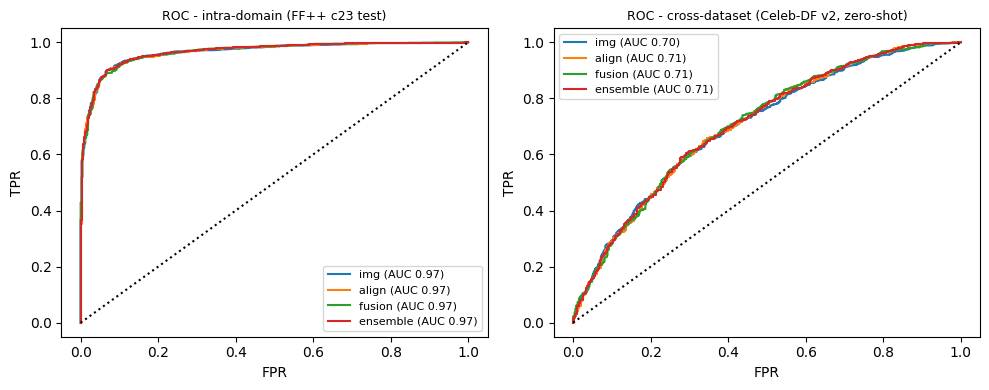


FF++ test, per manipulation method (that method's fakes vs all real faces), AUC:
  Deepfakes       img 0.978 | ensemble 0.979
  Face2Face       img 0.972 | ensemble 0.974
  FaceSwap        img 0.975 | ensemble 0.975
  NeuralTextures  img 0.936 | ensemble 0.938

saved results_clip.csv and preds.npz to Drive


In [ ]:
heads = ["img", "align", "fusion", "ensemble"]; tabs, preds = {}, {}
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a_, (split, nm) in zip(ax, [("test", "intra-domain (FF++ c23 test)"), ("unseen", "cross-dataset (Celeb-DF v2, zero-shot)")]):
    P, Y = predict(model, DATA[split]); preds[split] = (P, Y)
    tab = pd.DataFrame({h: metrics(Y, P[h]) for h in heads}).T; tabs[split] = tab
    print(f"\n{nm}:\n{tab.round(3).to_string()}")
    for h in heads:
        f, t, _ = roc_curve(Y, P[h]); a_.plot(f, t, label=f"{h} (AUC {roc_auc_score(Y, P[h]):.2f})")
    a_.plot([0, 1], [0, 1], "k:"); a_.set_title(f"ROC - {nm}", fontsize=9); a_.set_xlabel("FPR"); a_.set_ylabel("TPR"); a_.legend(fontsize=8)
plt.tight_layout(); plt.show()

P, Y = preds["test"]; meth = np.array([x["method"] for x in DATA["test"]])
print("\nFF++ test, per manipulation method (that method's fakes vs all real faces), AUC:")
for m in sorted(set(meth) - {"real"}):
    sel = (meth == m) | (Y == 0)
    print(f"  {m:15s} img {roc_auc_score(Y[sel], P['img'][sel]):.3f} | ensemble {roc_auc_score(Y[sel], P['ensemble'][sel]):.3f}")

pd.concat(tabs, names=["split", "head"]).to_csv(CK / "results_clip.csv")
np.savez(CK / "preds.npz", **{f"{s}_{h}": preds[s][0][h] for s in preds for h in heads}, **{f"{s}_y": preds[s][1] for s in preds})
print("\nsaved results_clip.csv and preds.npz to Drive")

this is only you need to run for all the above cells

In [ ]:
from google.colab import drive; drive.mount('/content/drive')
exec(open('/content/drive/MyDrive/refree/refree_lib.py').read())
assert 'build_model' in globals(), "Drive still has the OLD refree_lib.py - replace it with the new file"
FACES, DATA = load_all()
model = build_model(); load_best(model)

Mounted at /content/drive
refree_lib loaded | device: cuda
loading prompts from items_meta_v2.pkl
train    4312 items | real 2158 fake 2154
val       837 items | real 420 fake 417
test     2096 items | real 420 fake 1676
unseen   1547 items | real 531 fake 1016


tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  599MB            

model.safetensors: downloading bytes:           |  0.00B            

ThreeBranchCLIP: 149.9M parameters on cuda
restored best checkpoint from Drive


ThreeBranchCLIP(
  (clip): CLIPModel(
    (text_model): CLIPTextModel(
      (embeddings): CLIPTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPEncoderLayer(
            (self_attn): CLIPAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=2048, out_features=512, bias=True)
      

Cell 2: ablation (about 25–30 minutes, run it once and leave it)

In [ ]:
def variant(items, mode, seed=0):
    rng = random.Random(seed); out = [dict(it) for it in items]          # shallow copies, images are shared
    if mode == "blank":                                                  # no heuristic information at all
        for it in out:
            it["fusion_text"] = "Heuristic findings: none."
            it["align_text"] = FAKE_HDR if it["label"] else REAL_HDR
    elif mode == "shuffled":                                             # heuristic text from a random same-class face
        for lab in (0, 1):
            idx = [i for i, it in enumerate(items) if it["label"] == lab]; perm = idx[:]; rng.shuffle(perm)
            for i, j in zip(idx, perm):
                out[i]["fusion_text"], out[i]["align_text"] = items[j]["fusion_text"], items[j]["align_text"]
    return out

CK_MAIN = CK; CK = CK_MAIN / "ablation"; CK.mkdir(exist_ok=True)         # so the main checkpoint is NOT overwritten
RES = {}
for mode in ("blank", "shuffled"):
    random.seed(0); np.random.seed(0); torch.manual_seed(0)
    V = {s: variant(DATA[s], mode) for s in ("train", "val", "test", "unseen")}
    m = build_model(); train_model(m, V["train"], V["val"])
    RES[mode] = {}
    for s in ("test", "unseen"):
        P, Y = predict(m, V[s]); RES[mode][s] = {h: round(roc_auc_score(Y, P[h]), 3) for h in ("img", "align", "fusion", "ensemble")}
    print("RESULT", mode, RES[mode], flush=True)
    del m; torch.cuda.empty_cache()
CK = CK_MAIN
json.dump(RES, open(CK / "ablation_results.json", "w"))
print("full model (reference): test img .965 align .965 fusion .965 ens .966 | unseen img .703 align .705 fusion .707 ens .707")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

ThreeBranchCLIP: 149.9M parameters on cuda
smoke test OK (0.4s). Training 8 epochs on 4312 faces ...
epoch  1  loss=3.758  L_img=0.563  L_align=2.605  L_fusion=0.590  val_AUC_img=0.933  val_AUC_ens=0.931 | 88s
epoch  2  loss=3.139  L_img=0.327  L_align=2.457  L_fusion=0.355  val_AUC_img=0.976  val_AUC_ens=0.975 | 90s
epoch  3  loss=2.835  L_img=0.223  L_align=2.373  L_fusion=0.239  val_AUC_img=0.969  val_AUC_ens=0.970 | 91s
epoch  4  loss=2.766  L_img=0.209  L_align=2.346  L_fusion=0.211  val_AUC_img=0.976  val_AUC_ens=0.977 | 90s
epoch  5  loss=2.499  L_img=0.123  L_align=2.251  L_fusion=0.125  val_AUC_img=0.977  val_AUC_ens=0.976 | 90s
epoch  6  loss=2.269  L_img=0.052  L_align=2.167  L_fusion=0.051  val_AUC_img=0.979  val_AUC_ens=0.978 | 88s
epoch  7  loss=2.156  L_img=0.016  L_align=2.124  L_fusion=0.016  val_AUC_img=0.984  val_AUC_ens=0.984 | 96s
epoch  8  loss=2.152  L_img=0.013  L_align=2.127  L_fusion=0.013  val_AUC_img=0.985  val_AUC_ens=0.985 | 92s
restored best checkpoint fr

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

ThreeBranchCLIP: 149.9M parameters on cuda
smoke test OK (0.6s). Training 8 epochs on 4312 faces ...
epoch  1  loss=3.780  L_img=0.567  L_align=2.626  L_fusion=0.588  val_AUC_img=0.950  val_AUC_ens=0.950 | 91s
epoch  2  loss=3.009  L_img=0.286  L_align=2.411  L_fusion=0.312  val_AUC_img=0.966  val_AUC_ens=0.967 | 99s
epoch  3  loss=2.888  L_img=0.242  L_align=2.380  L_fusion=0.266  val_AUC_img=0.975  val_AUC_ens=0.974 | 96s
epoch  4  loss=2.774  L_img=0.210  L_align=2.341  L_fusion=0.223  val_AUC_img=0.971  val_AUC_ens=0.971 | 93s
epoch  5  loss=2.547  L_img=0.136  L_align=2.265  L_fusion=0.145  val_AUC_img=0.971  val_AUC_ens=0.971 | 87s
epoch  6  loss=2.258  L_img=0.050  L_align=2.159  L_fusion=0.049  val_AUC_img=0.980  val_AUC_ens=0.979 | 94s
epoch  7  loss=2.133  L_img=0.019  L_align=2.096  L_fusion=0.019  val_AUC_img=0.978  val_AUC_ens=0.978 | 92s
epoch  8  loss=2.071  L_img=0.007  L_align=2.058  L_fusion=0.006  val_AUC_img=0.979  val_AUC_ens=0.979 | 86s
restored best checkpoint fr

Cell 2: repeat with more seeds (about 50 minutes)

This trains the full model and the blank-text model with two new seeds each, to see how much the earlier gaps are just noise. It saves after every run and skips runs that are already done, so you can re-run it after a disconnect.

In [ ]:
def variant(items, mode):
    out = [dict(it) for it in items]
    if mode == "blank":
        for it in out:
            it["fusion_text"] = "Heuristic findings: none."
            it["align_text"] = FAKE_HDR if it["label"] else REAL_HDR
    return out

CK_MAIN = CK; CK = CK_MAIN / "ablation"; CK.mkdir(exist_ok=True)       # main checkpoint stays safe
fn = CK_MAIN / "seeds_results.json"
RES = json.load(open(fn)) if fn.exists() else {}
RES.setdefault("full_s0",  {"test": {"img": .965, "ens": .966}, "unseen": {"img": .703, "ens": .707}})   # earlier runs
RES.setdefault("blank_s0", {"test": {"img": .982, "ens": .982}, "unseen": {"img": .730, "ens": .736}})

for seed in (1, 2):
    for mode in ("full", "blank"):
        key = f"{mode}_s{seed}"
        if key in RES: continue
        random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
        V = {s: variant(DATA[s], mode) for s in ("train", "val", "test", "unseen")}
        m = build_model(); train_model(m, V["train"], V["val"])
        RES[key] = {}
        for s in ("test", "unseen"):
            P, Y = predict(m, V[s])
            RES[key][s] = {"img": round(float(roc_auc_score(Y, P["img"])), 3), "ens": round(float(roc_auc_score(Y, P["ensemble"])), 3)}
        json.dump(RES, open(fn, "w")); print("RESULT", key, RES[key], flush=True)
        del m; torch.cuda.empty_cache()
CK = CK_MAIN

print("\nmean +- std over seeds (ensemble AUC):")
for mode in ("full", "blank"):
    for s in ("test", "unseen"):
        v = np.array([RES[k][s]["ens"] for k in RES if k.startswith(mode + "_")])
        print(f"  {mode:6s} {s:7s} {v.mean():.3f} +- {v.std():.3f}  (n={len(v)}: {v.tolist()})")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

ThreeBranchCLIP: 149.9M parameters on cuda
smoke test OK (3.9s). Training 8 epochs on 4312 faces ...
epoch  1  loss=3.777  L_img=0.569  L_align=2.606  L_fusion=0.602  val_AUC_img=0.966  val_AUC_ens=0.967 | 110s
epoch  2  loss=2.931  L_img=0.295  L_align=2.323  L_fusion=0.313  val_AUC_img=0.970  val_AUC_ens=0.973 | 94s
epoch  3  loss=2.700  L_img=0.221  L_align=2.240  L_fusion=0.239  val_AUC_img=0.964  val_AUC_ens=0.964 | 92s
epoch  4  loss=2.425  L_img=0.131  L_align=2.149  L_fusion=0.145  val_AUC_img=0.977  val_AUC_ens=0.977 | 95s
epoch  5  loss=2.263  L_img=0.091  L_align=2.070  L_fusion=0.102  val_AUC_img=0.980  val_AUC_ens=0.980 | 95s
epoch  6  loss=2.038  L_img=0.033  L_align=1.972  L_fusion=0.034  val_AUC_img=0.982  val_AUC_ens=0.983 | 98s
epoch  7  loss=1.943  L_img=0.014  L_align=1.915  L_fusion=0.014  val_AUC_img=0.983  val_AUC_ens=0.983 | 103s
epoch  8  loss=1.899  L_img=0.003  L_align=1.893  L_fusion=0.003  val_AUC_img=0.983  val_AUC_ens=0.984 | 98s
restored best checkpoint 

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

ThreeBranchCLIP: 149.9M parameters on cuda
smoke test OK (0.5s). Training 8 epochs on 4312 faces ...
epoch  1  loss=3.747  L_img=0.551  L_align=2.604  L_fusion=0.591  val_AUC_img=0.968  val_AUC_ens=0.967 | 94s
epoch  2  loss=3.102  L_img=0.318  L_align=2.443  L_fusion=0.342  val_AUC_img=0.970  val_AUC_ens=0.972 | 93s
epoch  3  loss=2.942  L_img=0.264  L_align=2.400  L_fusion=0.278  val_AUC_img=0.970  val_AUC_ens=0.970 | 91s
epoch  4  loss=2.767  L_img=0.204  L_align=2.353  L_fusion=0.209  val_AUC_img=0.979  val_AUC_ens=0.979 | 98s
epoch  5  loss=2.556  L_img=0.142  L_align=2.274  L_fusion=0.141  val_AUC_img=0.986  val_AUC_ens=0.986 | 102s
epoch  6  loss=2.279  L_img=0.055  L_align=2.172  L_fusion=0.053  val_AUC_img=0.983  val_AUC_ens=0.984 | 90s
epoch  7  loss=2.162  L_img=0.017  L_align=2.130  L_fusion=0.015  val_AUC_img=0.983  val_AUC_ens=0.983 | 85s
epoch  8  loss=2.134  L_img=0.006  L_align=2.122  L_fusion=0.006  val_AUC_img=0.982  val_AUC_ens=0.983 | 85s
restored best checkpoint f

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

ThreeBranchCLIP: 149.9M parameters on cuda
smoke test OK (0.5s). Training 8 epochs on 4312 faces ...
epoch  1  loss=3.750  L_img=0.564  L_align=2.595  L_fusion=0.591  val_AUC_img=0.931  val_AUC_ens=0.931 | 103s
epoch  2  loss=3.072  L_img=0.338  L_align=2.377  L_fusion=0.357  val_AUC_img=0.966  val_AUC_ens=0.967 | 101s
epoch  3  loss=2.692  L_img=0.215  L_align=2.250  L_fusion=0.228  val_AUC_img=0.972  val_AUC_ens=0.973 | 100s
epoch  4  loss=2.405  L_img=0.133  L_align=2.128  L_fusion=0.143  val_AUC_img=0.972  val_AUC_ens=0.972 | 91s
epoch  5  loss=2.255  L_img=0.092  L_align=2.065  L_fusion=0.098  val_AUC_img=0.983  val_AUC_ens=0.982 | 91s
epoch  6  loss=2.065  L_img=0.040  L_align=1.988  L_fusion=0.037  val_AUC_img=0.978  val_AUC_ens=0.978 | 91s
epoch  7  loss=1.946  L_img=0.015  L_align=1.917  L_fusion=0.014  val_AUC_img=0.982  val_AUC_ens=0.982 | 93s
epoch  8  loss=1.912  L_img=0.009  L_align=1.896  L_fusion=0.007  val_AUC_img=0.982  val_AUC_ens=0.982 | 96s
restored best checkpoint

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

ThreeBranchCLIP: 149.9M parameters on cuda
smoke test OK (0.4s). Training 8 epochs on 4312 faces ...
epoch  1  loss=3.799  L_img=0.569  L_align=2.633  L_fusion=0.598  val_AUC_img=0.940  val_AUC_ens=0.938 | 97s
epoch  2  loss=3.124  L_img=0.326  L_align=2.449  L_fusion=0.349  val_AUC_img=0.979  val_AUC_ens=0.980 | 96s
epoch  3  loss=2.916  L_img=0.252  L_align=2.393  L_fusion=0.271  val_AUC_img=0.937  val_AUC_ens=0.937 | 91s
epoch  4  loss=2.762  L_img=0.207  L_align=2.345  L_fusion=0.210  val_AUC_img=0.965  val_AUC_ens=0.964 | 86s
epoch  5  loss=2.531  L_img=0.135  L_align=2.264  L_fusion=0.132  val_AUC_img=0.984  val_AUC_ens=0.984 | 92s
epoch  6  loss=2.272  L_img=0.051  L_align=2.172  L_fusion=0.049  val_AUC_img=0.979  val_AUC_ens=0.979 | 89s
epoch  7  loss=2.146  L_img=0.010  L_align=2.127  L_fusion=0.009  val_AUC_img=0.981  val_AUC_ens=0.981 | 85s
epoch  8  loss=2.142  L_img=0.008  L_align=2.124  L_fusion=0.010  val_AUC_img=0.981  val_AUC_ens=0.981 | 85s
restored best checkpoint fr

Get the final numbers

Run this small cell. It only reads the results already saved on Drive, so it needs no GPU and no restore cell, and it takes seconds:

In [ ]:
from google.colab import drive; drive.mount('/content/drive')
import json, numpy as np
RES = json.load(open('/content/drive/MyDrive/refree_ckpt/seeds_results.json'))
print("runs saved:", sorted(RES))
for mode in ("full", "blank"):
    for s in ("test", "unseen"):
        for h in ("img", "ens"):
            v = np.array([RES[k][s][h] for k in sorted(RES) if k.startswith(mode + "_")])
            print(f"{mode:6s} {s:7s} {h:3s} {v.mean():.3f} +- {v.std():.3f}  n={len(v)}  {v.tolist()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
runs saved: ['blank_s0', 'blank_s1', 'blank_s2', 'full_s0', 'full_s1', 'full_s2']
full   test    img 0.974 +- 0.007  n=3  [0.965, 0.978, 0.98]
full   test    ens 0.975 +- 0.006  n=3  [0.966, 0.978, 0.98]
full   unseen  img 0.727 +- 0.018  n=3  [0.703, 0.733, 0.746]
full   unseen  ens 0.730 +- 0.017  n=3  [0.707, 0.736, 0.747]
blank  test    img 0.982 +- 0.001  n=3  [0.982, 0.98, 0.983]
blank  test    ens 0.982 +- 0.001  n=3  [0.982, 0.98, 0.983]
blank  unseen  img 0.737 +- 0.014  n=3  [0.73, 0.724, 0.757]
blank  unseen  ens 0.741 +- 0.015  n=3  [0.736, 0.726, 0.761]


In [ ]:
import os
d = "/content/FaceForensics++/manipulated_sequences/Deepfakes/c23/videos"
print("FF++ videos on disk:", len(os.listdir(d)) if os.path.isdir(d) else "GONE")

FF++ videos on disk: GONE


Cell 1: get the script (once) and find a working server

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')
import os, shutil, urllib.request
S = "/content/drive/MyDrive/refree/download-FaceForensics.py"
if os.path.exists(S):
    shutil.copy(S, "/content/download-FaceForensics.py")
else:
    up = files.upload()                                   # choose download-FaceForensics.py
    shutil.move(list(up)[0], "/content/download-FaceForensics.py"); shutil.copy("/content/download-FaceForensics.py", S)

SERVERS = {"EU": "http://canis.vc.in.tum.de:8100/", "EU2": "http://kaldir.vc.in.tum.de/faceforensics/", "CA": "http://falas.cmpt.sfu.ca:8100/"}
ok = None
for n, b in SERVERS.items():
    try: urllib.request.urlopen(b + "v3/misc/filelist.json", timeout=15); ok = ok or n; print(n, "OK")
    except Exception as e: print(n, "FAIL")
print("using server:", ok)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
EU FAIL
EU2 OK
CA FAIL
using server: EU2


Cell 2: download FF++ c23 (about 10 GB)

In [ ]:
!echo "" | python /content/download-FaceForensics.py /content/FaceForensics++ -d original -c c23 -t videos --server {ok}
!echo "" | python /content/download-FaceForensics.py /content/FaceForensics++ -d Deepfakes -c c23 -t videos --server {ok}
!echo "" | python /content/download-FaceForensics.py /content/FaceForensics++ -d Face2Face -c c23 -t videos --server {ok}
!echo "" | python /content/download-FaceForensics.py /content/FaceForensics++ -d FaceSwap -c c23 -t videos --server {ok}
!echo "" | python /content/download-FaceForensics.py /content/FaceForensics++ -d NeuralTextures -c c23 -t videos --server {ok}

from pathlib import Path
FF = Path("/content/FaceForensics++")
for sub in ["original_sequences/youtube"] + [f"manipulated_sequences/{m}" for m in ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]]:
    print(f"{sub:45s}", len(list((FF / sub / "c23" / "videos").glob("*.mp4"))))

By pressing any key to continue you confirm that you have agreed to the FaceForensics terms of use as described at:
http://kaldir.vc.in.tum.de/faceforensics/webpage/FaceForensics_TOS.pdf
***
Press any key to continue, or CTRL-C to exit.
Output path: /content/FaceForensics++/original_sequences/youtube/c23/videos
100% 1000/1000 [30:11<00:00,  1.81s/it]
By pressing any key to continue you confirm that you have agreed to the FaceForensics terms of use as described at:
http://kaldir.vc.in.tum.de/faceforensics/webpage/FaceForensics_TOS.pdf
***
Press any key to continue, or CTRL-C to exit.
Output path: /content/FaceForensics++/manipulated_sequences/Deepfakes/c23/videos
100% 1000/1000 [30:30<00:00,  1.83s/it]
By pressing any key to continue you confirm that you have agreed to the FaceForensics terms of use as described at:
http://kaldir.vc.in.tum.de/faceforensics/webpage/FaceForensics_TOS.pdf
***
Press any key to continue, or CTRL-C to exit.
Output path: /content/FaceForensics++/manipulated_se

Cell 3: install dlib again (about 10 minutes, run after Cell 2 finishes)

In [ ]:
import os, sys, glob, shutil, subprocess
from google.colab import drive; drive.mount('/content/drive')
def run(cmd): subprocess.run(cmd, shell=True, check=True)

P = "/content/drive/MyDrive/refree/pkgs"; os.makedirs(P, exist_ok=True)
PRED = "/content/shape_predictor_68_face_landmarks.dat"
tag = f"cp{sys.version_info.major}{sys.version_info.minor}"

# 1) landmark model: download once, keep on Drive
if os.path.exists(f"{P}/shape_predictor_68_face_landmarks.dat"):
    shutil.copy(f"{P}/shape_predictor_68_face_landmarks.dat", PRED)
else:
    run("wget -q http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 -O /content/sp.bz2 && bzip2 -df /content/sp.bz2 && mv /content/sp /content/shape_predictor_68_face_landmarks.dat")
    shutil.copy(PRED, f"{P}/shape_predictor_68_face_landmarks.dat")

# 2) dlib: install from the cached wheel, or compile once and cache the wheel
whl = glob.glob(f"{P}/dlib-*-{tag}-*.whl")
if whl:
    run(f"pip install -q {whl[0]}")
else:
    print("compiling dlib once (~10 min); the wheel is kept on Drive for next time ...", flush=True)
    run("apt-get -qq install -y cmake build-essential")
    run(f"pip wheel -q dlib -w {P}")
    run(f"pip install -q {glob.glob(f'{P}/dlib-*-{tag}-*.whl')[0]}")

import dlib
print("dlib", dlib.__version__, "| predictor:", os.path.exists(PRED), "| python tag:", tag)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
compiling dlib once (~10 min); the wheel is kept on Drive for next time ...
dlib 20.0.1 | predictor: True | python tag: cp313


In [ ]:
# ===== Step R1: reference-based baseline - extract fake faces + their pristine counterparts (CPU is fine) =====
from google.colab import drive; drive.mount('/content/drive')
import os, glob, sys, subprocess
P = "/content/drive/MyDrive/refree/pkgs"
try: import dlib
except ImportError:                                            # restart-safe: reinstall dlib from the wheel cached on Drive
    tag = f"cp{sys.version_info.major}{sys.version_info.minor}"
    subprocess.run(f"pip install -q {glob.glob(f'{P}/dlib-*-{tag}-*.whl')[0]}", shell=True, check=True)
if not os.path.exists("/content/shape_predictor_68_face_landmarks.dat"):
    subprocess.run(f"cp {P}/shape_predictor_68_face_landmarks.dat /content/", shell=True, check=True)
exec(open('/content/drive/MyDrive/refree/refree_lib.py').read())

for sub in ["original_sequences/youtube"] + [f"manipulated_sequences/{m}" for m in ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]]:
    n = len(list((Path(cfg.FFPP_ROOT) / sub / "c23" / "videos").glob("*.mp4")))
    assert n == 1000, f"{sub}: {n}/1000 videos - wait for the download to finish (or re-run it)"

# ---------- extract fake faces + their PRISTINE counterparts (same alignment), cache to Drive ----------
FFR = Path(cfg.FFPP_ROOT)
REF = ROOT / "refree_refcache"; REF.mkdir(exist_ok=True)
METHODS = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]

def sample_idx(n, k=cfg.FRAMES_PER_VIDEO):
    return ((np.arange(k) + 0.5) * max(n, k) / k).astype(int)          # identical to the first extraction
def read_at(cap, idx):
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx)); ok, fr = cap.read(); return fr if ok else None
def bg_diff(a, b):                                                      # whole-frame difference: ~0 for the true pristine source
    g = lambda x: cv2.resize(cv2.cvtColor(x, cv2.COLOR_BGR2GRAY), (64, 64), interpolation=cv2.INTER_AREA).astype(np.float32)
    return float(np.abs(g(a) - g(b)).mean())

def process_video(method, stem):
    a, b = stem.split("_")
    cf = cv2.VideoCapture(str(FFR / "manipulated_sequences" / method / "c23" / "videos" / f"{stem}.mp4"))
    caps = {r: cv2.VideoCapture(str(FFR / "original_sequences/youtube/c23/videos" / f"{r}.mp4")) for r in dict.fromkeys((a, b))}
    nf = int(cf.get(cv2.CAP_PROP_FRAME_COUNT)); nr = {r: int(c.get(cv2.CAP_PROP_FRAME_COUNT)) for r, c in caps.items()}
    out = []
    for idx in sample_idx(nf):
        fk = read_at(cf, idx)
        if fk is None: continue
        reals = {r: read_at(c, min(int(idx), nr[r] - 1)) for r, c in caps.items()}
        if any(v is None for v in reals.values()): continue
        d = {r: bg_diff(fk, v) for r, v in reals.items()}
        rid = min(d, key=d.get); others = [v for r, v in d.items() if r != rid]
        lm = detect_landmarks_fast(fk)
        if lm is None: continue                                         # same skip rule as the first extraction
        M, _ = cv2.estimateAffinePartial2D(lm[STABLE_PTS], TEMPLATE_68[STABLE_PTS], method=cv2.LMEDS)
        rk = reals[rid]
        if rk.shape != fk.shape: rk = cv2.resize(rk, (fk.shape[1], fk.shape[0]))
        warp = lambda im: cv2.warpAffine(im, M, (S, S), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REFLECT)
        out.append(dict(fake=warp(fk), real=warp(rk), lm=(lm @ M[:, :2].T + M[:, 2]).astype(np.float32),
                        video=f"{method}/{stem}", method=method, pair=rid, first_is_pair=int(rid == a),
                        d_min=d[rid], d_other=(others[0] if others else np.nan)))
    for c in [cf, *caps.values()]: c.release()
    return out

def fake_videos(split):
    vids = {}
    for f in sorted(CACHE.glob(f"{split}_*.npz")):
        z = np.load(f); lab, vid, met = z["label"], z["video"], z["method"]
        for l, v, m in zip(lab, vid, met):
            if int(l) == 1: vids[str(v)] = str(m)
    return vids

def extract_ref(split, shard=100):
    vids = list(fake_videos(split).items()); n_sh = math.ceil(len(vids) / shard)
    for si in range(n_sh):
        f = REF / f"{split}_{si:03d}.npz"
        if f.exists(): continue
        recs, t0 = [], time.time()
        for v, m in vids[si * shard:(si + 1) * shard]:
            recs += process_video(m, v.split("/")[1])
        np.savez(f, fake=np.stack([r["fake"] for r in recs]), real=np.stack([r["real"] for r in recs]),
                 lms=np.stack([r["lm"] for r in recs]), video=np.array([r["video"] for r in recs]),
                 method=np.array([r["method"] for r in recs]), pair=np.array([r["pair"] for r in recs]),
                 first_is_pair=np.array([r["first_is_pair"] for r in recs]),
                 d_min=np.array([r["d_min"] for r in recs], np.float32), d_other=np.array([r["d_other"] for r in recs], np.float32))
        print(f"{split}: shard {si+1}/{n_sh} done in {time.time()-t0:.0f}s ({len(recs)} pairs)", flush=True)

def quick_check(n=2):
    cache = {}
    for f in sorted(CACHE.glob("val_*.npz")):
        z = np.load(f); lab, vid, im = z["label"], z["video"], z["imgs"]
        for l, v, x in zip(lab, vid, im):
            if int(l) == 1: cache.setdefault(str(v), []).append(x)
    vids = fake_videos("val"); t0 = time.time(); rows = []
    for m in METHODS:
        for v in [v for v, mm in vids.items() if mm == m][:n]:
            recs = process_video(m, v.split("/")[1]); old = cache[v]
            dd = np.mean([np.abs(r["fake"].astype(int) - o.astype(int)).mean() for r, o in zip(recs, old)]) if recs else np.nan
            rows.append((v, len(old), len(recs), round(float(dd), 2), recs[0]["first_is_pair"] if recs else -1,
                         round(recs[0]["d_min"], 1) if recs else np.nan, round(recs[0]["d_other"], 1) if recs else np.nan))
    df = pd.DataFrame(rows, columns=["video", "faces_before", "faces_now", "crop_diff", "first_id_is_pair", "d_pair", "d_other"])
    print(df.to_string(index=False)); print(f"{len(rows)} videos in {time.time()-t0:.0f}s  (~{(time.time()-t0)/len(rows):.1f}s/video)")
    assert (df.faces_before == df.faces_now).all(), "face counts differ from the first extraction - paste this table to Claude"
    assert df.crop_diff.max() < 3, "re-extracted fake crops do not match the cached ones - paste this table to Claude"
    assert (df.d_pair < 0.7 * df.d_other).all(), "pristine source not clearly identified - paste this table to Claude"
    print("QUICK CHECK PASSED: same crops as before, pristine partner identified\n")

quick_check()
for sp in ("val", "test", "train"):
    extract_ref(sp)

rows = []
for f in sorted(REF.glob("*.npz")):
    z = np.load(f); rows.append(pd.DataFrame(dict(method=z["method"], first=z["first_is_pair"], d_min=z["d_min"], d_other=z["d_other"])))
R = pd.concat(rows)
print(R.groupby("method").agg(pairs=("first", "size"), first_id_is_pair=("first", "mean"), d_pair=("d_min", "median"), d_other=("d_other", "median")).round(2))
print("ambiguous pairs (d_pair > 0.7*d_other):", int((R.d_min > 0.7 * R.d_other).sum()), "of", len(R))
print("ALL DONE")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
refree_lib loaded | device: cuda
                 video  faces_before  faces_now  crop_diff  first_id_is_pair  d_pair  d_other
     Deepfakes/827_817             3          3        0.0                 1     1.1     84.4
     Deepfakes/585_599             3          3        0.0                 1     0.7     49.8
     Face2Face/827_817             3          3        0.0                 1     0.5     83.1
     Face2Face/585_599             3          3        0.0                 1     0.4     52.5
      FaceSwap/827_817             3          3        0.0                 1     0.7     84.0
      FaceSwap/585_599             3          3        0.0                 1     0.6     49.6
NeuralTextures/827_817             3          3        0.0                 1     0.6     83.9
NeuralTextures/585_599             3          3        0.0                 1     0.6  

What this baseline is

I'd call it a rule-based reference-annotation baseline, not a full reproduction of the paper's pipeline. For each fake face it computes |i_r − i_f| from the pristine twin, thresholds it (Otsu), and writes captions naming the facial regions the difference covers, such as "Manipulated regions: mouth, left eye". The paper additionally refines captions with a multimodal LLM, which we aren't doing. In your report, describe it as "same model, trained with reference-derived region annotations", and don't claim it reproduces FFTG. Its captions name regions but not artifact types, since the difference mask can't tell us the type.

How it's evaluated, so the comparison is fair
Training: the baseline sees reference-based captions (fakes get region text, reals get the "real" caption).
Validation, test and Celeb-DF: no reference text is given (the text is the same blank placeholder for every face). That mimics the isolated-image setting your project targets, and Celeb-DF has no pairs anyway. Because the image and alignment heads never read the text at inference, they're the cleanest comparison. The fusion head and the ensemble are evaluated with the blank text, so they may look worse than before.
Oracle (FF++ test only): it also reports what happens if the reference text is supplied at test time. That is an upper bound and a leaked one, so treat it as a ceiling, not a result.

In [ ]:
from google.colab import drive; drive.mount('/content/drive')
exec(open('/content/drive/MyDrive/refree/refree_lib.py').read())
assert 'build_model' in globals(), "Drive still has the OLD refree_lib.py"
# ===== Step R2: reference-based annotations from the pairs (rule-based baseline) =====
FACES, DATA = load_all()
REF = ROOT / "refree_refcache"
REF_BLANK = "Reference findings: none."

def ref_regions(fake, real, lm):
    m = cv2.GaussianBlur(np.abs(fake.astype(np.float32) - real.astype(np.float32)).mean(2) / 255.0, (0, 0), 2)
    if np.percentile(m, 99) < 0.05: return []
    _, b = cv2.threshold((m / max(float(m.max()), 1e-6) * 255).astype(np.uint8), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    b = b > 0; masks = region_masks(lm); out = []
    for r in REGION_NAMES:
        fr = float(b[masks[r]].mean()) if masks[r].any() else 0.0
        if fr >= 0.25: out.append((r, "high" if fr > 0.6 else "medium" if fr > 0.4 else "low", fr))
    return sorted(out, key=lambda t: -t[2])

def ref_texts(regs):
    if not regs: return REF_BLANK, FAKE_HDR + " Subtle manipulation, region not localized."
    return ("Reference findings: " + "; ".join(f"{r} ({s})" for r, s, _ in regs[:3]) + ".",
            FAKE_HDR + " Manipulated regions: " + ", ".join(r for r, _, _ in regs[:3]) + ".")

def load_ref(split):
    d = {}
    for f in sorted(REF.glob(f"{split}_*.npz")):
        z = np.load(f); fk, rl, lm, vid = z["fake"], z["real"], z["lms"], z["video"]
        for i in range(len(vid)): d.setdefault(str(vid[i]), []).append((fk[i], rl[i], lm[i]))
    return d

def make_variants(split):
    REFT = [dict(it) for it in DATA[split]]; BLANK = [dict(it) for it in DATA[split]]
    pairs = load_ref(split) if split in ("train", "val", "test") else {}; seen = {}; n_reg = []
    for i, it in enumerate(DATA[split]):
        BLANK[i]["fusion_text"] = REF_BLANK; BLANK[i]["align_text"] = FAKE_HDR if it["label"] else REAL_HDR
        if it["label"] == 0: REFT[i]["fusion_text"], REFT[i]["align_text"] = REF_BLANK, REAL_HDR; continue
        if not pairs: continue
        k = seen.get(it["video"], 0); seen[it["video"]] = k + 1
        fk, rl, lm = pairs[it["video"]][k]
        assert np.abs(fk.astype(int) - it["img"].astype(int)).mean() < 1, f"{split}: pair/face mismatch for {it['video']}"
        regs = ref_regions(fk, rl, lm); REFT[i]["fusion_text"], REFT[i]["align_text"] = ref_texts(regs); n_reg.append(regs)
    if pairs: assert sum(len(v) for v in pairs.values()) == len(n_reg), f"{split}: {len(n_reg)} fake faces but {sum(len(v) for v in pairs.values())} reference pairs - is the extraction finished?"
    return REFT, BLANK, n_reg

VAR = {s: make_variants(s) for s in ("train", "val", "test", "unseen")}
for s in ("train", "val", "test"):
    regs = VAR[s][2]; cnt = {r: sum(any(x[0] == r for x in rg) for rg in regs) for r in REGION_NAMES}
    print(f"{s}: fake faces with >=1 reference region: {sum(len(r) > 0 for r in regs)}/{len(regs)} | per region: {cnt}")
ex = next(v for v in VAR["train"][0] if v["label"] == 1 and v["fusion_text"] != REF_BLANK)
print("example baseline caption:", ex["fusion_text"], "|", ex["align_text"])

# ===== Step R3: retrain with the reference-based annotations (3 seeds), evaluate on isolated images =====
CK_MAIN = CK; CK = CK_MAIN / "ablation"; CK.mkdir(exist_ok=True)       # main checkpoint stays safe
fn = CK_MAIN / "seeds_results.json"
RES = json.load(open(fn)) if fn.exists() else {}
H = (("img", "img"), ("align", "align"), ("fusion", "fusion"), ("ens", "ensemble"))
for seed in (0, 1, 2):
    key = f"ref_s{seed}"
    if key in RES: continue
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    m = build_model(); train_model(m, VAR["train"][0], VAR["val"][1])      # train with reference text, select epoch on text-free val
    RES[key] = {}
    for s in ("test", "unseen"):
        P, Y = predict(m, VAR[s][1])                                       # isolated image: no reference text at inference
        RES[key][s] = {a: round(float(roc_auc_score(Y, P[b])), 3) for a, b in H}
    P, Y = predict(m, VAR["test"][0])                                      # oracle: reference text given at test time (upper bound)
    RES[key]["test_oracle"] = {a: round(float(roc_auc_score(Y, P[b])), 3) for a, b in H}
    json.dump(RES, open(fn, "w")); print("RESULT", key, RES[key], flush=True)
    del m; torch.cuda.empty_cache()
CK = CK_MAIN

print("\n=== mean +- std over seeds (AUC) ===")
for mode in ("full", "blank", "ref"):
    for s in ("test", "unseen"):
        for h in ("img", "ens"):
            v = np.array([RES[k][s][h] for k in sorted(RES) if k.startswith(mode + "_")])
            print(f"  {mode:5s} {s:7s} {h:3s} {v.mean():.3f} +- {v.std():.3f}  n={len(v)}")
v = np.array([RES[k]["test_oracle"]["ens"] for k in sorted(RES) if k.startswith("ref_")])
print(f"  ref oracle (reference text at test, FF++ only) ens {v.mean():.3f} +- {v.std():.3f}")
print("ALL DONE")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
refree_lib loaded | device: cuda
loading prompts from items_meta_v2.pkl
train    4312 items | real 2158 fake 2154
val       837 items | real 420 fake 417
test     2096 items | real 420 fake 1676
unseen   1547 items | real 531 fake 1016
train: fake faces with >=1 reference region: 2062/2154 | per region: {'left eye': 1186, 'right eye': 1180, 'nose': 1155, 'mouth': 1823, 'face boundary': 167}
val: fake faces with >=1 reference region: 401/417 | per region: {'left eye': 215, 'right eye': 218, 'nose': 231, 'mouth': 357, 'face boundary': 16}
test: fake faces with >=1 reference region: 1609/1676 | per region: {'left eye': 940, 'right eye': 925, 'nose': 914, 'mouth': 1388, 'face boundary': 133}
example baseline caption: Reference findings: nose (high); mouth (medium); left eye (medium). | A fake face with manipulated regions and blending artifacts. Manipulated regio

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

ThreeBranchCLIP: 149.9M parameters on cuda
smoke test OK (3.7s). Training 8 epochs on 4312 faces ...
epoch  1  loss=3.401  L_img=0.566  L_align=2.522  L_fusion=0.313  val_AUC_img=0.912  val_AUC_ens=0.894 | 110s
epoch  2  loss=2.569  L_img=0.291  L_align=2.195  L_fusion=0.084  val_AUC_img=0.964  val_AUC_ens=0.960 | 100s
epoch  3  loss=2.311  L_img=0.196  L_align=2.054  L_fusion=0.060  val_AUC_img=0.980  val_AUC_ens=0.982 | 96s
epoch  4  loss=2.086  L_img=0.119  L_align=1.939  L_fusion=0.028  val_AUC_img=0.973  val_AUC_ens=0.948 | 93s
epoch  5  loss=1.901  L_img=0.064  L_align=1.818  L_fusion=0.019  val_AUC_img=0.982  val_AUC_ens=0.983 | 97s
epoch  6  loss=1.712  L_img=0.021  L_align=1.684  L_fusion=0.007  val_AUC_img=0.980  val_AUC_ens=0.975 | 94s
epoch  7  loss=1.570  L_img=0.008  L_align=1.559  L_fusion=0.003  val_AUC_img=0.985  val_AUC_ens=0.983 | 101s
epoch  8  loss=1.491  L_img=0.004  L_align=1.487  L_fusion=0.001  val_AUC_img=0.985  val_AUC_ens=0.983 | 93s
restored best checkpoint

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

ThreeBranchCLIP: 149.9M parameters on cuda
smoke test OK (0.6s). Training 8 epochs on 4312 faces ...
epoch  1  loss=3.390  L_img=0.554  L_align=2.509  L_fusion=0.327  val_AUC_img=0.969  val_AUC_ens=0.970 | 97s
epoch  2  loss=2.516  L_img=0.272  L_align=2.167  L_fusion=0.077  val_AUC_img=0.968  val_AUC_ens=0.963 | 94s
epoch  3  loss=2.250  L_img=0.178  L_align=2.024  L_fusion=0.047  val_AUC_img=0.977  val_AUC_ens=0.977 | 101s
epoch  4  loss=2.036  L_img=0.096  L_align=1.915  L_fusion=0.025  val_AUC_img=0.975  val_AUC_ens=0.973 | 93s
epoch  5  loss=1.871  L_img=0.061  L_align=1.792  L_fusion=0.019  val_AUC_img=0.982  val_AUC_ens=0.982 | 109s
epoch  6  loss=1.694  L_img=0.020  L_align=1.668  L_fusion=0.006  val_AUC_img=0.985  val_AUC_ens=0.983 | 109s
epoch  7  loss=1.555  L_img=0.005  L_align=1.549  L_fusion=0.001  val_AUC_img=0.986  val_AUC_ens=0.983 | 104s
epoch  8  loss=1.484  L_img=0.002  L_align=1.481  L_fusion=0.000  val_AUC_img=0.986  val_AUC_ens=0.984 | 109s
restored best checkpoi

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

ThreeBranchCLIP: 149.9M parameters on cuda
smoke test OK (0.5s). Training 8 epochs on 4312 faces ...
epoch  1  loss=3.423  L_img=0.571  L_align=2.537  L_fusion=0.316  val_AUC_img=0.944  val_AUC_ens=0.946 | 101s
epoch  2  loss=2.568  L_img=0.298  L_align=2.191  L_fusion=0.079  val_AUC_img=0.894  val_AUC_ens=0.887 | 94s
epoch  3  loss=2.230  L_img=0.172  L_align=2.011  L_fusion=0.047  val_AUC_img=0.982  val_AUC_ens=0.979 | 100s
epoch  4  loss=2.055  L_img=0.109  L_align=1.914  L_fusion=0.032  val_AUC_img=0.975  val_AUC_ens=0.975 | 93s
epoch  5  loss=1.844  L_img=0.049  L_align=1.781  L_fusion=0.013  val_AUC_img=0.980  val_AUC_ens=0.969 | 89s
epoch  6  loss=1.686  L_img=0.016  L_align=1.663  L_fusion=0.006  val_AUC_img=0.983  val_AUC_ens=0.981 | 102s
epoch  7  loss=1.546  L_img=0.010  L_align=1.533  L_fusion=0.003  val_AUC_img=0.984  val_AUC_ens=0.982 | 103s
epoch  8  loss=1.485  L_img=0.005  L_align=1.479  L_fusion=0.001  val_AUC_img=0.984  val_AUC_ens=0.982 | 92s
restored best checkpoin

Step 1: localization (about 5 minutes)

What it measures: whether the reference-free anomaly map points at the manipulated area. Proxy ground truth is the pristine-vs-fake difference mask we already extracted (the official FF++ mask videos would be stronger, but this is a reasonable first check, and the report should say so). It also reports a center-prior baseline, the average position of manipulations on train faces. A detector that can't beat that has learned nothing beyond "faces have their middle in the middle".

Mounted at /content/drive
refree_lib loaded | device: cuda
loading prompts from items_meta_v2.pkl
train    4312 items | real 2158 fake 2154
val       837 items | real 420 fake 417
test     2096 items | real 420 fake 1676
unseen   1547 items | real 531 fake 1016
center-prior built from 2147 train pairs
  32/1676 faces (2s)
  512/1676 faces (39s)
  992/1676 faces (77s)
  1472/1676 faces (116s)

PIXEL-LEVEL localization on 1654 FF++ test fakes: mean ROC-AUC of each map vs the proxy mask (0.5 = chance)
          mean  std over faces
fused    0.560           0.149
srm      0.536           0.136
fft      0.544           0.118
sym_tex  0.523           0.102
sym_res  0.493           0.083
ae       0.561           0.105
center   0.815           0.159

per manipulation method (mean AUC):
                fused  center
method                       
Deepfakes       0.596   0.927
Face2Face       0.555   0.730
FaceSwap        0.525   0.886
NeuralTextures  0.564   0.713

REGION-LEVEL agreement with th

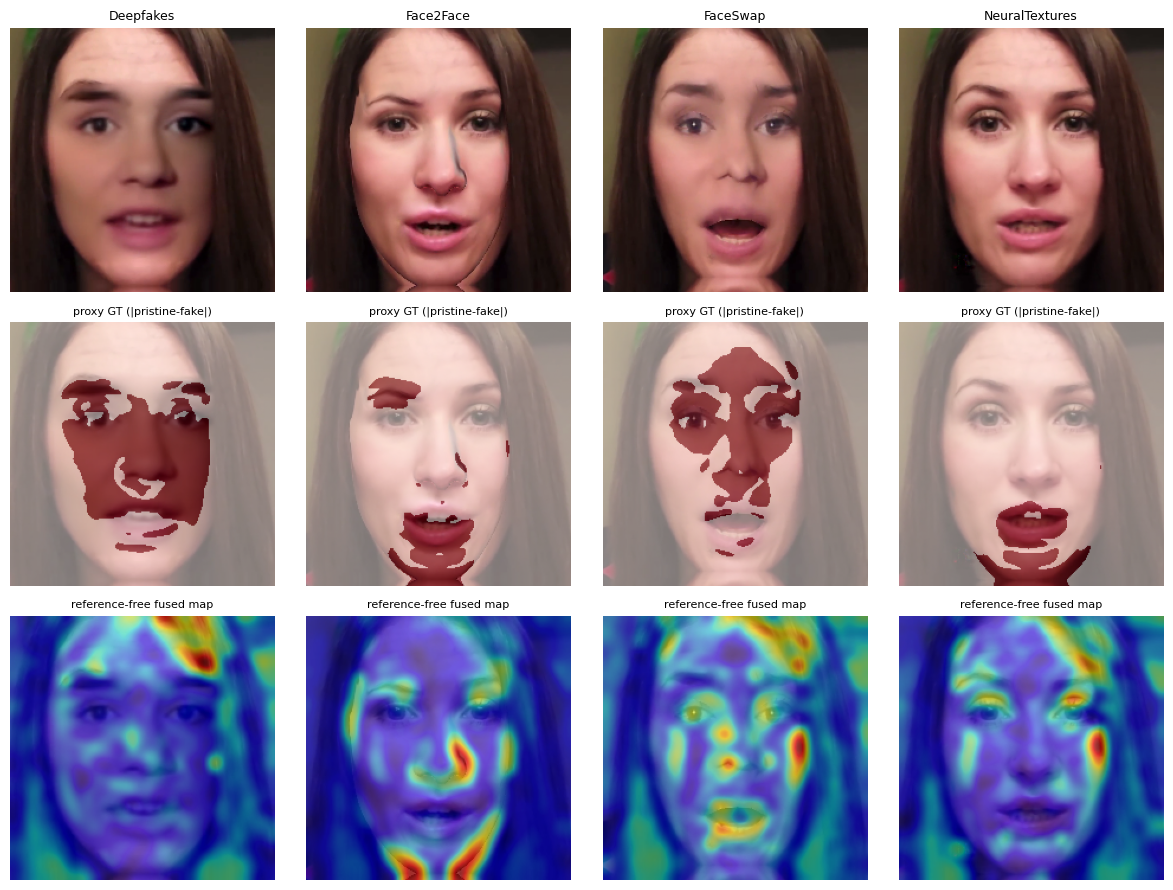


saved localization_results.json and localization_examples.png to Drive


In [1]:
# ===== Step 1: do the reference-free priors localize the manipulated region? (proxy ground truth = |pristine - fake|) =====
from google.colab import drive; drive.mount('/content/drive')
exec(open('/content/drive/MyDrive/refree/refree_lib.py').read())
assert 'build_model' in globals(), "Drive still has the OLD refree_lib.py"
FACES, DATA = load_all()
REF = ROOT / "refree_refcache"
priors, analyzer = load_priors()
va_real = [it for it in DATA["val"] if it["label"] == 0]
analyzer.calibrate([it["img"] for it in va_real], [it["lm"] for it in va_real])      # same v2 thresholds as the prompts

def load_ref(split):
    d = {}
    for f in sorted(REF.glob(f"{split}_*.npz")):
        z = np.load(f); fk, rl, lm, vid = z["fake"], z["real"], z["lms"], z["video"]
        for i in range(len(vid)): d.setdefault(str(vid[i]), []).append((fk[i], rl[i], lm[i]))
    return d

def ref_mask(fk, rl):
    m = cv2.GaussianBlur(np.abs(fk.astype(np.float32) - rl.astype(np.float32)).mean(2) / 255.0, (0, 0), 2)
    if np.percentile(m, 99) < 0.05: return None
    _, b = cv2.threshold((m / max(float(m.max()), 1e-6) * 255).astype(np.uint8), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return b > 0

def mask_regions(b, lm):
    masks = region_masks(lm)
    return [r for r in REGION_NAMES if masks[r].any() and float(b[masks[r]].mean()) >= 0.25]

# spatial-prior baseline: where are manipulations on average? (from TRAIN pairs only). Any detector should beat this.
tp = load_ref("train"); acc = np.zeros((S, S)); n = 0
for L in tp.values():
    for fk, rl, lm in L:
        b = ref_mask(fk, rl)
        if b is not None: acc += b; n += 1
CENTER = cv2.GaussianBlur((acc / n).astype(np.float32), (0, 0), 6); del tp
print(f"center-prior built from {n} train pairs")

MAPS = ["fused", "srm", "fft", "sym_tex", "sym_res", "ae", "center"]
pairs = load_ref("test"); seen = {}
fake_idx = [i for i, it in enumerate(DATA["test"]) if it["label"] == 1]
px, examples = [], {}
def add(cnt, pred, gt):
    cnt += np.array([len(set(pred) & set(gt)), len(set(pred) - set(gt)), len(set(gt) - set(pred))])
cnt_p, cnt_m, cnt_a = np.zeros(3), np.zeros(3), np.zeros(3)
t0 = time.time()
for c in range(0, len(fake_idx), 32):
    its = [DATA["test"][i] for i in fake_idx[c:c + 32]]
    Z = priors.z_maps([it["img"] for it in its], [it["lm"] for it in its])
    for it, z in zip(its, Z):
        k = seen.get(it["video"], 0); seen[it["video"]] = k + 1
        fk, rl, lm = pairs[it["video"]][k]
        assert np.abs(fk.astype(int) - it["img"].astype(int)).mean() < 1, f"pair/face mismatch for {it['video']}"
        b = ref_mask(fk, rl)
        if b is None or b.sum() < 50 or b.mean() > 0.8: continue
        fused = priors.fuse(z); reg, _ = analyzer._region_stats(z, fused, it["lm"])
        maps = dict(fused=fused, center=CENTER, **{p: z[p] for p in PRIOR_NAMES}); y = b[::2, ::2].ravel()
        px.append(dict(method=it["method"], **{nm: roc_auc_score(y, mp[::2, ::2].ravel()) for nm, mp in maps.items()}))
        gt = mask_regions(b, it["lm"]); pred = [r for r in REGION_NAMES if reg[r] > analyzer.reg_thr[r]]
        add(cnt_p, pred, gt); add(cnt_m, ["mouth"], gt); add(cnt_a, REGION_NAMES, gt)
        examples.setdefault(it["method"], (it["img"], b, fused))
    if (c // 32) % 15 == 0: print(f"  {min(c + 32, len(fake_idx))}/{len(fake_idx)} faces ({time.time()-t0:.0f}s)", flush=True)

P = pd.DataFrame(px)
print(f"\nPIXEL-LEVEL localization on {len(P)} FF++ test fakes: mean ROC-AUC of each map vs the proxy mask (0.5 = chance)")
print(P[MAPS].agg(["mean", "std"]).T.round(3).rename(columns={"std": "std over faces"}).to_string())
print("\nper manipulation method (mean AUC):"); print(P.groupby("method")[["fused", "center"]].mean().round(3).to_string())
def prf(c): p = c[0] / max(c[0] + c[1], 1); r = c[0] / max(c[0] + c[2], 1); return dict(precision=round(p, 3), recall=round(r, 3), F1=round(2 * p * r / max(p + r, 1e-9), 3))
R = pd.DataFrame({"reference-free priors": prf(cnt_p), "always 'mouth'": prf(cnt_m), "all 5 regions": prf(cnt_a)}).T
print("\nREGION-LEVEL agreement with the reference regions (micro-averaged over faces):"); print(R.to_string())

import matplotlib.pyplot as plt
fig, ax = plt.subplots(3, len(examples), figsize=(3 * len(examples), 9), squeeze=False)
for j, (m, (im, b, fu)) in enumerate(sorted(examples.items())):
    ax[0, j].imshow(im[..., ::-1]); ax[0, j].set_title(m, fontsize=9)
    ax[1, j].imshow(im[..., ::-1]); ax[1, j].imshow(b, alpha=0.5, cmap="Reds"); ax[1, j].set_title("proxy GT (|pristine-fake|)", fontsize=8)
    ax[2, j].imshow(im[..., ::-1]); ax[2, j].imshow(fu, alpha=0.55, cmap="jet"); ax[2, j].set_title("reference-free fused map", fontsize=8)
for a in ax.ravel(): a.axis("off")
plt.tight_layout(); plt.savefig(CK / "localization_examples.png", dpi=130); plt.show()
json.dump(dict(pixel_auc_mean=P[MAPS].mean().round(4).to_dict(), by_method=P.groupby("method")[["fused", "center"]].mean().round(4).to_dict(),
               region_level=R.to_dict(), n_faces=len(P)), open(CK / "localization_results.json", "w"), indent=1)
print("\nsaved localization_results.json and localization_examples.png to Drive")

Step 2: LLaVA explanation head (needs the T4 GPU runtime)

Two cells, each self-contained. I could not test the model parts (my sandbox has no GPU, torch or the model). I did test the surrounding logic: target construction, balanced sampling, the JSON parser with a truncated-output fallback, and the region metrics. A failure on first run is plausible, especially around bitsandbytes or peft versions on your Colab, so the training cell prints GPU memory after its first step. If it breaks, paste the traceback.

Design in short: LLaVA-1.5-7B in 4-bit with LoRA on the language model. It trains on 600 faces (300 real, 300 fake across the 4 methods) for one epoch. The training answer is a JSON whose regions and artifacts come from the reference-free priors, which keeps the project's claim intact. Expect about 40–60 minutes for training, plus the download of about 14 GB the first time.

In [ ]:
# ===== Step 2a: LLaVA-1.5-7B + QLoRA -> explanation head (TRAIN). Needs the T4 GPU runtime. =====
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "peft", "bitsandbytes", "accelerate"], check=True)
from google.colab import drive; drive.mount('/content/drive')
exec(open('/content/drive/MyDrive/refree/refree_lib.py').read())
assert 'build_model' in globals(), "Drive still has the OLD refree_lib.py"
assert DEVICE == "cuda", "switch the runtime to the T4 GPU"
FACES, DATA = load_all()
import re
from PIL import Image
from transformers import AutoProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, set_peft_model_state_dict

INSTR = ("You are a face-forensics assistant. Decide whether this face image is real or manipulated. Answer with one JSON object with the keys "
         "verdict (real or fake), regions (facial regions with severity), artifacts (list) and reasoning (one sentence).")

def target_json(it):
    pj, fake = it["prompt"], it["label"] == 1
    regs = pj["manipulated_regions"][:3] if fake else []
    arts = sorted({a for d in regs for a in d["artifacts"]})[:3]
    if fake and regs: reasoning = pj["reasoning"]
    elif fake: reasoning = "Subtle manipulation; no region clearly exceeds the real-face statistics."
    else: reasoning = "Texture, noise and symmetry are consistent with a natural face."
    return json.dumps(dict(verdict="fake" if fake else "real", regions=[f"{d['region']} ({d['severity']})" for d in regs],
                           artifacts=arts, reasoning=reasoning[:240]))

def pick_balanced(items, n_real, per_method, seed=0):
    rng = random.Random(seed); reals = [i for i, it in enumerate(items) if it["label"] == 0]; by = {}
    for i, it in enumerate(items):
        if it["label"] == 1: by.setdefault(it["method"], []).append(i)
    sel = rng.sample(reals, min(n_real, len(reals)))
    for m, L in sorted(by.items()): sel += rng.sample(L, min(per_method, len(L)))
    rng.shuffle(sel); return sel

N_REAL, PER_METHOD, ACC, LR = 300, 75, 8, 2e-4           # 300 real + 4x75 fake = 600 training faces, 1 epoch
sel = pick_balanced(DATA["train"], N_REAL, PER_METHOD); N = len(sel)
TARGET = {i: target_json(DATA["train"][i]) for i in sel}
print(f"{N} training faces | fake targets with >=1 region: {sum(json.loads(TARGET[i])['regions'] != [] for i in sel if DATA['train'][i]['label'] == 1)}/{N - N_REAL}")
print("example target:", TARGET[next(i for i in sel if DATA['train'][i]['label'] == 1)])

MID = "llava-hf/llava-1.5-7b-hf"
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)
processor = AutoProcessor.from_pretrained(MID)
try: model = LlavaForConditionalGeneration.from_pretrained(MID, quantization_config=bnb, dtype=torch.float16, device_map={"": 0})
except TypeError: model = LlavaForConditionalGeneration.from_pretrained(MID, quantization_config=bnb, torch_dtype=torch.float16, device_map={"": 0})
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
model = get_peft_model(model, LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05, task_type="CAUSAL_LM",
                                         target_modules=r".*language_model.*\.(q_proj|k_proj|v_proj|o_proj)"))   # LoRA on the language model only
model.print_trainable_parameters()

def encode(it, answer=None):
    img = Image.fromarray(np.ascontiguousarray(it["img"][..., ::-1]))
    prompt = processor.apply_chat_template([{"role": "user", "content": [{"type": "text", "text": INSTR}, {"type": "image"}]}], add_generation_prompt=True)
    if answer is None: return processor(images=img, text=prompt, return_tensors="pt"), None
    full = processor(images=img, text=prompt + " " + answer + processor.tokenizer.eos_token, return_tensors="pt")
    n_prompt = processor(images=img, text=prompt, return_tensors="pt")["input_ids"].shape[1]
    labels = full["input_ids"].clone(); labels[:, :n_prompt] = -100                 # loss only on the answer
    return full, labels
to_gpu = lambda d: {k: (v.to(0, torch.float16) if v.is_floating_point() else v.to(0)) for k, v in d.items()}

OUT = CK / "llava_lora"; OUT.mkdir(exist_ok=True); STATE = OUT / "state.json"; (OUT / "instr.txt").write_text(INSTR)
n_done = 0
if STATE.exists():                                                                    # resume after a disconnect
    from safetensors.torch import load_file
    set_peft_model_state_dict(model, load_file(str(OUT / "adapter_model.safetensors")))
    n_done = json.load(open(STATE))["n_done"]; print("resuming from sample", n_done)

params = [p for p in model.parameters() if p.requires_grad]
opt = torch.optim.AdamW(params, lr=LR, weight_decay=0.0)
scaler = torch.amp.GradScaler("cuda")
model.train(); run, t0 = [], time.time()
for n in range(n_done, N):
    inp, lab = encode(DATA["train"][sel[n]], TARGET[sel[n]])
    with torch.autocast("cuda", dtype=torch.float16):
        loss = model(**to_gpu(inp), labels=lab.to(0)).loss / ACC
    scaler.scale(loss).backward(); run.append(loss.item() * ACC)
    if (n + 1) % ACC == 0:
        for g in opt.param_groups: g["lr"] = LR * min(1.0, (n + 1) / (0.05 * N)) * max(0.05, 1 - n / N)     # warm-up then linear decay
        scaler.unscale_(opt); nn.utils.clip_grad_norm_(params, 1.0); scaler.step(opt); scaler.update(); opt.zero_grad(set_to_none=True)
    if n == n_done: print(f"first step OK | GPU memory {torch.cuda.max_memory_allocated()/1e9:.1f} GB", flush=True)
    if (n + 1) % 25 == 0: print(f"sample {n+1}/{N} | loss(last 25) {np.mean(run[-25:]):.3f} | {(time.time()-t0)/(n+1-n_done):.1f}s/sample", flush=True)
    if (n + 1) % 150 == 0: model.save_pretrained(str(OUT)); json.dump({"n_done": n + 1}, open(STATE, "w"))
model.save_pretrained(str(OUT)); json.dump({"n_done": N}, open(STATE, "w"))
print("TRAINING DONE | adapter saved to", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
refree_lib loaded | device: cuda
loading prompts from items_meta_v2.pkl
train    4312 items | real 2158 fake 2154
val       837 items | real 420 fake 417
test     2096 items | real 420 fake 1676
unseen   1547 items | real 531 fake 1016
600 training faces | fake targets with >=1 region: 58/300
example target: {"verdict": "fake", "regions": [], "artifacts": [], "reasoning": "Subtle manipulation; no region clearly exceeds the real-face statistics."}


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

trainable params: 16,777,216 || all params: 7,080,204,288 || trainable%: 0.2370


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


first step OK | GPU memory 6.3 GB
sample 25/600 | loss(last 25) 1.483 | 2.7s/sample
sample 50/600 | loss(last 25) 0.867 | 2.8s/sample
sample 75/600 | loss(last 25) 0.344 | 2.9s/sample
sample 100/600 | loss(last 25) 0.339 | 2.9s/sample
sample 125/600 | loss(last 25) 0.192 | 2.9s/sample
sample 150/600 | loss(last 25) 0.238 | 2.9s/sample
sample 175/600 | loss(last 25) 0.139 | 2.9s/sample
sample 200/600 | loss(last 25) 0.166 | 2.9s/sample
sample 225/600 | loss(last 25) 0.106 | 3.0s/sample
sample 250/600 | loss(last 25) 0.040 | 3.0s/sample
sample 275/600 | loss(last 25) 0.080 | 3.0s/sample
sample 300/600 | loss(last 25) 0.048 | 3.0s/sample
sample 325/600 | loss(last 25) 0.098 | 3.0s/sample
sample 350/600 | loss(last 25) 0.043 | 3.0s/sample
sample 375/600 | loss(last 25) 0.034 | 3.0s/sample
sample 400/600 | loss(last 25) 0.046 | 3.0s/sample
sample 425/600 | loss(last 25) 0.030 | 3.0s/sample
sample 450/600 | loss(last 25) 0.029 | 3.0s/sample
sample 475/600 | loss(last 25) 0.056 | 3.0s/sample


Cell 2b: evaluate (run after 2a prints TRAINING DONE; about 25–30 minutes)

In [ ]:
# ===== Step 2b: evaluate the LLaVA explanation head =====
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "peft", "bitsandbytes", "accelerate"], check=True)
from google.colab import drive; drive.mount('/content/drive')
exec(open('/content/drive/MyDrive/refree/refree_lib.py').read())
assert 'build_model' in globals(), "Drive still has the OLD refree_lib.py"
assert DEVICE == "cuda", "switch the runtime to the T4 GPU"
FACES, DATA = load_all()
import re
from PIL import Image
from transformers import AutoProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig
from peft import PeftModel
REF = ROOT / "refree_refcache"; OUT = CK / "llava_lora"
INSTR = (OUT / "instr.txt").read_text()                                                # exactly the instruction used in training

def pick_balanced(items, n_real, per_method, seed=0):
    rng = random.Random(seed); reals = [i for i, it in enumerate(items) if it["label"] == 0]; by = {}
    for i, it in enumerate(items):
        if it["label"] == 1: by.setdefault(it["method"], []).append(i)
    sel = rng.sample(reals, min(n_real, len(reals)))
    for m, L in sorted(by.items()): sel += rng.sample(L, min(per_method, len(L)))
    rng.shuffle(sel); return sel

def parse_out(txt):
    d = None; m = re.search(r"\{.*\}", txt, re.S)
    if m:
        try: d = json.loads(m.group(0))
        except Exception: d = None
    v = d.get("verdict") if isinstance(d, dict) else None
    if v not in ("real", "fake"):
        mv = re.search(r'verdict"?\s*:\s*"?(real|fake)', txt); v = mv.group(1) if mv else None
    regs = d.get("regions") if isinstance(d, dict) else None
    rt = " ".join(map(str, regs)) if isinstance(regs, list) else txt
    return v, [r for r in REGION_NAMES if r in rt.lower()], d is not None

def prf(c):
    p = c[0] / max(c[0] + c[1], 1); r = c[0] / max(c[0] + c[2], 1)
    return dict(precision=round(float(p), 3), recall=round(float(r), 3), F1=round(float(2 * p * r / max(p + r, 1e-9)), 3))
def tally(cnt, pred, gt): cnt += np.array([len(set(pred) & set(gt)), len(set(pred) - set(gt)), len(set(gt) - set(pred))])

def load_ref(split):
    d = {}
    for f in sorted(REF.glob(f"{split}_*.npz")):
        z = np.load(f); fk, rl, vid = z["fake"], z["real"], z["video"]
        for i in range(len(vid)): d.setdefault(str(vid[i]), []).append((fk[i], rl[i]))
    return d
def ref_region_names(fk, rl, lm):
    m = cv2.GaussianBlur(np.abs(fk.astype(np.float32) - rl.astype(np.float32)).mean(2) / 255.0, (0, 0), 2)
    if np.percentile(m, 99) < 0.05: return []
    _, b = cv2.threshold((m / max(float(m.max()), 1e-6) * 255).astype(np.uint8), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    b = b > 0; masks = region_masks(lm)
    return [r for r in REGION_NAMES if masks[r].any() and float(b[masks[r]].mean()) >= 0.25]

MID = "llava-hf/llava-1.5-7b-hf"
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)
processor = AutoProcessor.from_pretrained(MID)
try: base = LlavaForConditionalGeneration.from_pretrained(MID, quantization_config=bnb, dtype=torch.float16, device_map={"": 0})
except TypeError: base = LlavaForConditionalGeneration.from_pretrained(MID, quantization_config=bnb, torch_dtype=torch.float16, device_map={"": 0})
model = PeftModel.from_pretrained(base, str(OUT)); model.eval()
to_gpu = lambda d: {k: (v.to(0, torch.float16) if v.is_floating_point() else v.to(0)) for k, v in d.items()}

@torch.no_grad()
def explain(it):
    img = Image.fromarray(np.ascontiguousarray(it["img"][..., ::-1]))
    prompt = processor.apply_chat_template([{"role": "user", "content": [{"type": "text", "text": INSTR}, {"type": "image"}]}], add_generation_prompt=True)
    inp = to_gpu(processor(images=img, text=prompt, return_tensors="pt"))
    out = model.generate(**inp, max_new_tokens=170, do_sample=False)
    return processor.batch_decode(out[:, inp["input_ids"].shape[1]:], skip_special_tokens=True)[0].strip()

# reference regions for the FF++ test fakes (proxy ground truth), matched by video + occurrence
pairs = load_ref("test"); occ, seen = {}, {}
for i, it in enumerate(DATA["test"]):
    if it["label"] == 1: occ[i] = seen.get(it["video"], 0); seen[it["video"]] = occ[i] + 1

SETS = {"ffpp_test": ("test", pick_balanced(DATA["test"], 40, 10)), "celebdf": ("unseen", pick_balanced(DATA["unseen"], 20, 20))}
RES, gens = {}, []; cnt_l, cnt_p, cnt_m = np.zeros(3), np.zeros(3), np.zeros(3); t0 = time.time()
for name, (split, idxs) in SETS.items():
    ok = tp = tn = nfake = nreal = parsed = claims_on_real = 0
    for j, i in enumerate(idxs):
        it = DATA[split][i]; txt = explain(it); v, regs, okjson = parse_out(txt); fake = it["label"] == 1
        parsed += okjson; nfake += fake; nreal += (not fake); ok += (v == ("fake" if fake else "real"))
        tp += (fake and v == "fake"); tn += ((not fake) and v == "real"); claims_on_real += ((not fake) and len(regs) > 0)
        if name == "ffpp_test" and fake:
            fk, rl = pairs[it["video"]][occ[i]]; gt = ref_region_names(fk, rl, it["lm"])
            tally(cnt_l, regs, gt); tally(cnt_p, [d["region"] for d in it["prompt"]["manipulated_regions"][:3]], gt); tally(cnt_m, ["mouth"], gt)
        gens.append(dict(set=name, method=it["method"], label=it["label"], output=txt))
        if (j + 1) % 20 == 0: print(f"  {name}: {j+1}/{len(idxs)} ({(time.time()-t0)/60:.1f} min)", flush=True)
    RES[name] = dict(n=len(idxs), verdict_accuracy=round(ok / len(idxs), 3), fake_recall=round(tp / max(nfake, 1), 3), real_recall=round(tn / max(nreal, 1), 3),
                     valid_json=round(parsed / len(idxs), 3), regions_claimed_on_real=round(claims_on_real / max(nreal, 1), 3))
RES["region_agreement_vs_reference (FF++ test fakes)"] = {"LLaVA explanations": prf(cnt_l), "reference-free priors (training target)": prf(cnt_p), "always 'mouth'": prf(cnt_m)}
json.dump(dict(results=RES, generations=gens), open(CK / "llava_eval.json", "w"), indent=1)
print("\n" + json.dumps(RES, indent=1))
print("\n--- example explanations ---")
for g in [x for x in gens if x["set"] == "ffpp_test"][:6]: print(f"[{g['method']:15s} label={g['label']}] {g['output'][:300]}")
print("\nsaved llava_eval.json to Drive | ALL DONE")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
refree_lib loaded | device: cuda
loading prompts from items_meta_v2.pkl
train    4312 items | real 2158 fake 2154
val       837 items | real 420 fake 417
test     2096 items | real 420 fake 1676
unseen   1547 items | real 531 fake 1016


Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

  ffpp_test: 20/80 (1.5 min)
  ffpp_test: 40/80 (2.9 min)
  ffpp_test: 60/80 (4.3 min)
  ffpp_test: 80/80 (5.8 min)
  celebdf: 20/40 (7.2 min)
  celebdf: 40/40 (8.6 min)

{
 "ffpp_test": {
  "n": 80,
  "verdict_accuracy": 0.65,
  "fake_recall": 0.375,
  "real_recall": 0.925,
  "valid_json": 1.0,
  "regions_claimed_on_real": 0.0
 },
 "celebdf": {
  "n": 40,
  "verdict_accuracy": 0.5,
  "fake_recall": 0.05,
  "real_recall": 0.95,
  "valid_json": 1.0,
  "regions_claimed_on_real": 0.0
 },
 "region_agreement_vs_reference (FF++ test fakes)": {
  "LLaVA explanations": {
   "precision": 0.0,
   "recall": 0.0,
   "F1": 0.0
  },
  "reference-free priors (training target)": {
   "precision": 0.75,
   "recall": 0.084,
   "F1": 0.151
  },
  "always 'mouth'": {
   "precision": 0.875,
   "recall": 0.327,
   "F1": 0.476
  }
 }
}

--- example explanations ---
[real            label=0] {"verdict": "real", "regions": [], "artifacts": [], "reasoning": "Texture, noise and symmetry are consistent with a nat

What I need from you

A diagnostic cell that only reads saved files (no GPU, no model, a few seconds):

In [ ]:
from google.colab import drive; drive.mount('/content/drive')
import json, os, re, pickle, collections, numpy as np
CK = "/content/drive/MyDrive/refree_ckpt"
st = f"{CK}/llava_lora/state.json"
print("training progress:", open(st).read() if os.path.exists(st) else "no state file")
E = json.load(open(f"{CK}/llava_eval.json"))["generations"]
vd = lambda t: (re.search(r'verdict"?\s*:\s*"?(real|fake)', t) or [None, "?"])[1]
print("(set, true label, verdict, empty regions):")
for k, v in sorted(collections.Counter((g["set"], g["label"], vd(g["output"]), '"regions": []' in g["output"]) for g in E).items()): print("  ", k, v)
print("distinct outputs:", len({g["output"] for g in E}), "of", len(E))
M = pickle.load(open(f"{CK}/items_meta_v2.pkl", "rb"))
fk = [x for x in M["train"] if x["label"] == 1]
print("train fakes whose target has >=1 region:", round(float(np.mean([len(x["prompt"]["manipulated_regions"]) > 0 for x in fk])), 3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
training progress: {"n_done": 600}
(set, true label, verdict, empty regions):
   ('celebdf', 0, 'fake', True) 1
   ('celebdf', 0, 'real', True) 19
   ('celebdf', 1, 'fake', True) 1
   ('celebdf', 1, 'real', True) 19
   ('ffpp_test', 0, 'fake', True) 3
   ('ffpp_test', 0, 'real', True) 37
   ('ffpp_test', 1, 'fake', True) 15
   ('ffpp_test', 1, 'real', True) 25
distinct outputs: 2 of 120
train fakes whose target has >=1 region: 0.175


Since the LLaVA head didn't produce usable explanations, here is a cell that builds an explainable output without it. For eight test faces (one fake per manipulation method plus two real ones), it shows:

the verdict and probability from the trained CLIP model, which is the part that works (about 0.97 AUC),
the evidence from the reference-free priors as a heat map and a text list of flagged regions and artifact types,
the proxy ground truth (pristine vs fake difference) beside it, so the audience can see honestly where the evidence agrees or doesn't.

It's a template-based explanation (the verdict comes from CLIP, the evidence from the priors), not generated language. Say that when you present it. I tested the logic on synthetic data; the CLIP and prior loading use the same functions that already ran on your Colab. It runs in a minute or two, as one self-contained cell:

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
refree_lib loaded | device: cuda
loading prompts from items_meta_v2.pkl
train    4312 items | real 2158 fake 2154
val       837 items | real 420 fake 417
test     2096 items | real 420 fake 1676
unseen   1547 items | real 531 fake 1016


tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  599MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

ThreeBranchCLIP: 149.9M parameters on cuda
restored best checkpoint from Drive
[NeuralTextures  true=fake] Verdict: FAKE (CLIP fake-probability 0.84). Reference-free evidence: no region exceeds the real-face thresholds. Reference regions (proxy ground truth): mouth.

[Face2Face       true=fake] Verdict: FAKE (CLIP fake-probability 0.95). Reference-free evidence: no region exceeds the real-face thresholds. Reference regions (proxy ground truth): right eye, mouth, face boundary.

[FaceSwap        true=fake] Verdict: FAKE (CLIP fake-probability 0.93). Reference-free evidence: no region exceeds the real-face thresholds. Reference regions (proxy ground truth): left eye, right eye, nose, mouth.

[Deepfakes       true=fake] Verdict: FAKE (CLIP fake-probability 0.95). Reference-free evidence: no region exceeds the real-face thresholds. Reference regions (proxy ground truth): left eye, right eye, nose, mouth.

[real            true=real] Verdict: REAL (CLIP fake-probability 0.11). Reference-fre

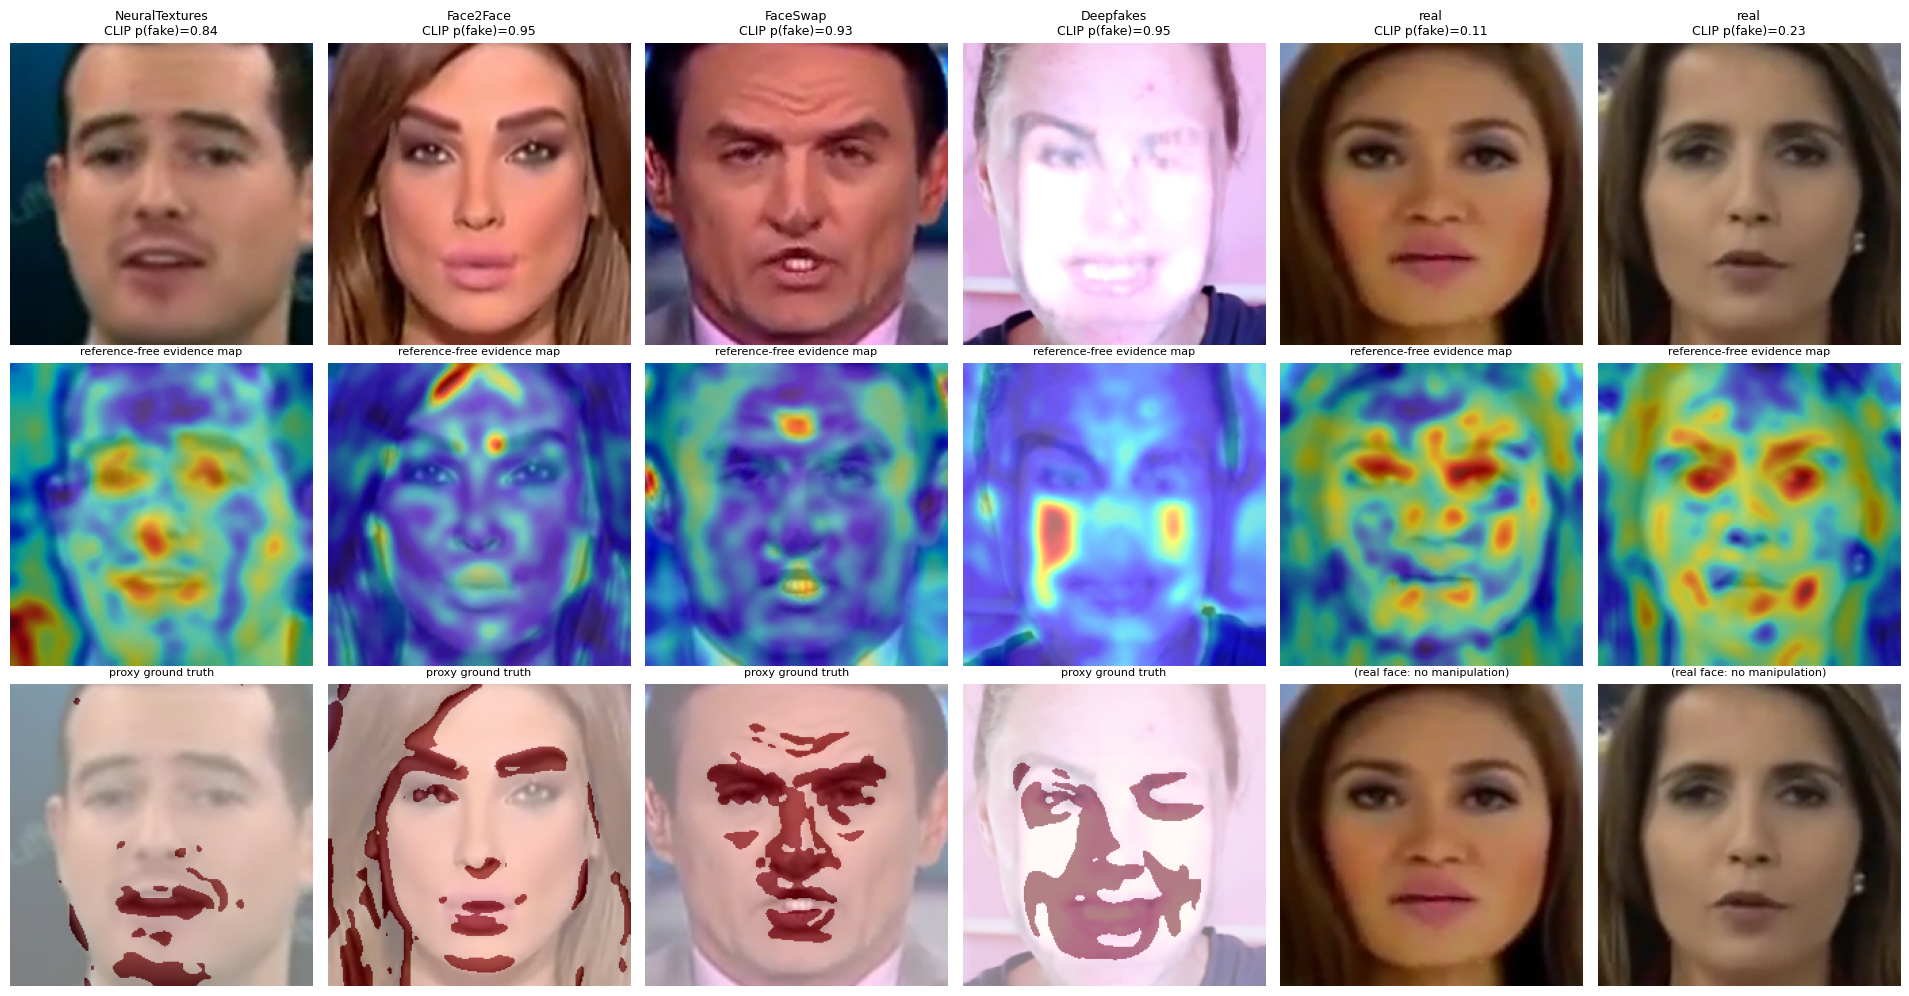

saved explanation_demo.png and explanation_demo.json to Drive | ALL DONE


In [2]:
# ===== Step 3: explainable-output demo = CLIP verdict + reference-free evidence + reference regions (no LLaVA) =====
from google.colab import drive; drive.mount('/content/drive')
exec(open('/content/drive/MyDrive/refree/refree_lib.py').read())
assert 'build_model' in globals(), "Drive still has the OLD refree_lib.py"
FACES, DATA = load_all()
model = build_model(); load_best(model)
priors, analyzer = load_priors()
va_real = [it for it in DATA["val"] if it["label"] == 0]
analyzer.calibrate([it["img"] for it in va_real], [it["lm"] for it in va_real])
REF = ROOT / "refree_refcache"

def load_ref(split):
    d = {}
    for f in sorted(REF.glob(f"{split}_*.npz")):
        z = np.load(f); fk, rl, vid = z["fake"], z["real"], z["video"]
        for i in range(len(vid)): d.setdefault(str(vid[i]), []).append((fk[i], rl[i]))
    return d
def ref_mask(fk, rl):
    m = cv2.GaussianBlur(np.abs(fk.astype(np.float32) - rl.astype(np.float32)).mean(2) / 255.0, (0, 0), 2)
    if np.percentile(m, 99) < 0.05: return None
    _, b = cv2.threshold((m / max(float(m.max()), 1e-6) * 255).astype(np.uint8), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return b > 0
def mask_regions(b, lm):
    masks = region_masks(lm)
    return [r for r in REGION_NAMES if masks[r].any() and float(b[masks[r]].mean()) >= 0.25]

pairs = load_ref("test"); occ, seen = {}, {}
for i, it in enumerate(DATA["test"]):
    if it["label"] == 1: occ[i] = seen.get(it["video"], 0); seen[it["video"]] = occ[i] + 1

rng = random.Random(1); fake_ids = [i for i, it in enumerate(DATA["test"]) if it["label"] == 1]; rng.shuffle(fake_ids)
chosen, got = [], set()                                                   # one fake per manipulation method + two real faces
for i in fake_ids:
    it = DATA["test"][i]
    if it["method"] in got: continue
    b = ref_mask(*pairs[it["video"]][occ[i]])
    if b is None or b.sum() < 50 or b.mean() > 0.8: continue
    chosen.append((i, b)); got.add(it["method"])
for i in rng.sample([i for i, it in enumerate(DATA["test"]) if it["label"] == 0], 2): chosen.append((i, None))
items = [DATA["test"][i] for i, _ in chosen]
P, Y = predict(model, items); prob = P["img"]
Z = priors.z_maps([it["img"] for it in items], [it["lm"] for it in items])

def explain_text(p, pj, gt):
    ev = "; ".join(f"{d['region']} ({d['severity']}: {', '.join(d['artifacts'][:2])})" for d in pj["manipulated_regions"][:3]) or "no region exceeds the real-face thresholds"
    s = f"Verdict: {'FAKE' if p > 0.5 else 'REAL'} (CLIP fake-probability {p:.2f}). Reference-free evidence: {ev}."
    return s + (f" Reference regions (proxy ground truth): {', '.join(gt) or 'none'}." if gt is not None else "")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(3, len(items), figsize=(3.2 * len(items), 10), squeeze=False); out = []
for j, ((i, b), it, z, p) in enumerate(zip(chosen, items, Z, prob)):
    fused = priors.fuse(z); reg, pri = analyzer._region_stats(z, fused, it["lm"])
    pj = analyzer.prompt(dict(fused=fused, reg=reg, pri=pri, spec=radial_spectrum(it["img"])), f"demo_{j}")
    gt = mask_regions(b, it["lm"]) if b is not None else None
    txt = explain_text(float(p), pj, gt); out.append(dict(method=it["method"], true_label=it["label"], explanation=txt)); print(f"[{it['method']:15s} true={'fake' if it['label'] else 'real'}] {txt}\n")
    ax[0, j].imshow(it["img"][..., ::-1]); ax[0, j].set_title(f"{it['method']}\nCLIP p(fake)={p:.2f}", fontsize=9)
    ax[1, j].imshow(it["img"][..., ::-1]); ax[1, j].imshow(fused, alpha=0.55, cmap="jet"); ax[1, j].set_title("reference-free evidence map", fontsize=8)
    ax[2, j].imshow(it["img"][..., ::-1])
    if b is not None: ax[2, j].imshow(b, alpha=0.5, cmap="Reds")
    ax[2, j].set_title("proxy ground truth" if b is not None else "(real face: no manipulation)", fontsize=8)
for a in ax.ravel(): a.axis("off")
plt.tight_layout(); plt.savefig(CK / "explanation_demo.png", dpi=130); plt.show()
json.dump(out, open(CK / "explanation_demo.json", "w"), indent=1)
print("saved explanation_demo.png and explanation_demo.json to Drive | ALL DONE")

One cheap test: do the priors add anything to CLIP?

So far we used the priors as hand-fused heuristics. But earlier a learned combination of the same 35 features reached AUC 0.71 on FF++ test and 0.58 on Celeb-DF by themselves, so they do hold signal that needs learned signs. They might also carry cues CLIP lacks (noise and frequency artifacts), which is the original motivation. This cell combines CLIP's score with a classifier trained on the priors, using weights you can see. It needs no retraining and takes about 2 minutes. It is self-contained, so run it on its own:

In [3]:
# ===== Do the reference-free priors add information that CLIP does not already have? (learned combination, no retraining) =====
from google.colab import drive; drive.mount('/content/drive')
exec(open('/content/drive/MyDrive/refree/refree_lib.py').read())
assert 'build_model' in globals(), "Drive still has the OLD refree_lib.py"
FACES, DATA = load_all()
model = build_model(); load_best(model)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X = {s: np.stack([x["features"] for x in DATA[s]]) for s in DATA}; Y = {s: np.array([x["label"] for x in DATA[s]]) for s in DATA}
priors_clf = make_pipeline(StandardScaler(), LogisticRegression(C=0.3, max_iter=2000)).fit(X["train"], Y["train"])   # the 35 prior features, trained on TRAIN only
logit = lambda p: np.log(np.clip(p, 1e-6, 1 - 1e-6) / (1 - np.clip(p, 1e-6, 1 - 1e-6)))
SP = ("val", "test", "unseen")
C = {s: logit(predict(model, DATA[s])[0]["img"]) for s in SP}                      # CLIP image-head score
Q = {s: priors_clf.decision_function(X[s]) for s in SP}                            # priors-only score
z = lambda a, ref: (a - ref.mean()) / ref.std()                                    # standardise with VAL statistics only

print("single scores (AUC):")
print("  CLIP image head :", {s: round(roc_auc_score(Y[s], C[s]), 3) for s in SP})
print("  priors only     :", {s: round(roc_auc_score(Y[s], Q[s]), 3) for s in SP})
rows = []
for w in (0.0, 0.1, 0.25, 0.5, 1.0):
    rows.append(dict(weight_on_priors=w, **{s: round(roc_auc_score(Y[s], z(C[s], C["val"]) + w * z(Q[s], Q["val"])), 3) for s in SP}))
print("\nCLIP + w * priors (AUC; w = 0 is CLIP alone):"); print(pd.DataFrame(rows).to_string(index=False))
print("\nThe whole table is reported, not just the best row. A gain on Celeb-DF that is not matched on FF++ val/test would be a hint, not a result.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
refree_lib loaded | device: cuda
loading prompts from items_meta_v2.pkl
train    4312 items | real 2158 fake 2154
val       837 items | real 420 fake 417
test     2096 items | real 420 fake 1676
unseen   1547 items | real 531 fake 1016


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

ThreeBranchCLIP: 149.9M parameters on cuda
restored best checkpoint from Drive
single scores (AUC):
  CLIP image head : {'val': np.float64(0.978), 'test': np.float64(0.965), 'unseen': np.float64(0.703)}
  priors only     : {'val': np.float64(0.701), 'test': np.float64(0.682), 'unseen': np.float64(0.55)}

CLIP + w * priors (AUC; w = 0 is CLIP alone):
 weight_on_priors   val  test  unseen
             0.00 0.978 0.965   0.703
             0.10 0.977 0.964   0.698
             0.25 0.973 0.959   0.687
             0.50 0.963 0.945   0.668
             1.00 0.927 0.908   0.638

The whole table is reported, not just the best row. A gain on Celeb-DF that is not matched on FF++ val/test would be a hint, not a result.


The augmentation cell retrains your model (reference-free text, same recipe) with training-time degradations: random crop, low-resolution round trip, blur, JPEG compression and brightness/contrast changes. The epoch is still selected on clean validation faces, and test and Celeb-DF are untouched. It runs 3 seeds so it can be compared with your earlier "full" runs (0.974 ± 0.007 on FF++, 0.727 ± 0.018 on Celeb-DF). I'll test the augmentation function first.

The augmentation function works. It runs in about 1.4 ms per face, so it adds no real overhead, and it keeps the crop shape and type intact. Run this as one cell by itself (about 40–45 minutes):

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
refree_lib loaded | device: cuda
loading prompts from items_meta_v2.pkl
train    4312 items | real 2158 fake 2154
val       837 items | real 420 fake 417
test     2096 items | real 420 fake 1676
unseen   1547 items | real 531 fake 1016


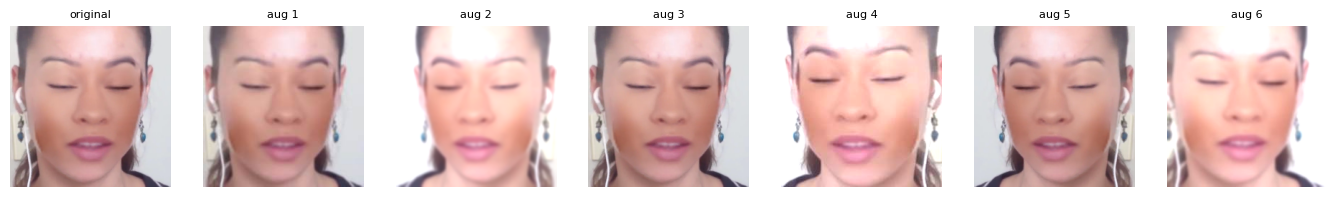

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

ThreeBranchCLIP: 149.9M parameters on cuda
smoke test OK (0.6s). Training 8 epochs on 4312 faces ...
epoch  1  loss=4.037  L_img=0.649  L_align=2.730  L_fusion=0.657  val_AUC_img=0.863  val_AUC_ens=0.869 | 119s
epoch  2  loss=3.365  L_img=0.434  L_align=2.476  L_fusion=0.455  val_AUC_img=0.943  val_AUC_ens=0.943 | 104s
epoch  3  loss=3.006  L_img=0.330  L_align=2.325  L_fusion=0.350  val_AUC_img=0.963  val_AUC_ens=0.963 | 114s
epoch  4  loss=2.699  L_img=0.234  L_align=2.219  L_fusion=0.246  val_AUC_img=0.946  val_AUC_ens=0.944 | 98s
epoch  5  loss=2.546  L_img=0.188  L_align=2.154  L_fusion=0.204  val_AUC_img=0.964  val_AUC_ens=0.964 | 106s
epoch  6  loss=2.320  L_img=0.119  L_align=2.068  L_fusion=0.133  val_AUC_img=0.975  val_AUC_ens=0.977 | 110s
epoch  7  loss=2.135  L_img=0.069  L_align=1.990  L_fusion=0.076  val_AUC_img=0.975  val_AUC_ens=0.976 | 98s
epoch  8  loss=2.078  L_img=0.052  L_align=1.968  L_fusion=0.059  val_AUC_img=0.975  val_AUC_ens=0.976 | 93s
restored best checkpoi

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

ThreeBranchCLIP: 149.9M parameters on cuda
smoke test OK (0.5s). Training 8 epochs on 4312 faces ...
epoch  1  loss=4.010  L_img=0.634  L_align=2.724  L_fusion=0.653  val_AUC_img=0.903  val_AUC_ens=0.900 | 109s
epoch  2  loss=3.402  L_img=0.451  L_align=2.486  L_fusion=0.465  val_AUC_img=0.908  val_AUC_ens=0.908 | 104s
epoch  3  loss=3.025  L_img=0.338  L_align=2.336  L_fusion=0.351  val_AUC_img=0.945  val_AUC_ens=0.945 | 111s
epoch  4  loss=2.718  L_img=0.245  L_align=2.221  L_fusion=0.253  val_AUC_img=0.950  val_AUC_ens=0.950 | 109s
epoch  5  loss=2.496  L_img=0.173  L_align=2.138  L_fusion=0.185  val_AUC_img=0.963  val_AUC_ens=0.965 | 107s
epoch  6  loss=2.375  L_img=0.139  L_align=2.095  L_fusion=0.142  val_AUC_img=0.968  val_AUC_ens=0.968 | 110s
epoch  7  loss=2.181  L_img=0.084  L_align=2.009  L_fusion=0.089  val_AUC_img=0.967  val_AUC_ens=0.966 | 98s
epoch  8  loss=2.095  L_img=0.057  L_align=1.977  L_fusion=0.061  val_AUC_img=0.967  val_AUC_ens=0.967 | 93s
restored best checkpo

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

ThreeBranchCLIP: 149.9M parameters on cuda
smoke test OK (0.6s). Training 8 epochs on 4312 faces ...
epoch  1  loss=4.000  L_img=0.634  L_align=2.716  L_fusion=0.649  val_AUC_img=0.880  val_AUC_ens=0.876 | 99s
epoch  2  loss=3.376  L_img=0.446  L_align=2.469  L_fusion=0.461  val_AUC_img=0.931  val_AUC_ens=0.932 | 110s
epoch  3  loss=3.028  L_img=0.337  L_align=2.339  L_fusion=0.352  val_AUC_img=0.945  val_AUC_ens=0.946 | 116s
epoch  4  loss=2.812  L_img=0.271  L_align=2.257  L_fusion=0.284  val_AUC_img=0.957  val_AUC_ens=0.956 | 111s
epoch  5  loss=2.557  L_img=0.189  L_align=2.165  L_fusion=0.203  val_AUC_img=0.960  val_AUC_ens=0.961 | 115s
epoch  6  loss=2.370  L_img=0.134  L_align=2.090  L_fusion=0.146  val_AUC_img=0.976  val_AUC_ens=0.976 | 113s
epoch  7  loss=2.182  L_img=0.079  L_align=2.014  L_fusion=0.089  val_AUC_img=0.974  val_AUC_ens=0.974 | 99s
epoch  8  loss=2.096  L_img=0.057  L_align=1.978  L_fusion=0.061  val_AUC_img=0.976  val_AUC_ens=0.976 | 93s
restored best checkpoi

In [4]:
# ===== Augmentation experiment: same model + reference-free text, but trained with realistic degradations (3 seeds) =====
from google.colab import drive; drive.mount('/content/drive')
exec(open('/content/drive/MyDrive/refree/refree_lib.py').read())
assert 'build_model' in globals(), "Drive still has the OLD refree_lib.py"
FACES, DATA = load_all()

def augment(im):
    h, w = im.shape[:2]
    if random.random() < 0.5: im = im[:, ::-1]                                          # horizontal flip
    if random.random() < 0.5:                                                           # random crop (80-100 % of the side), resized back
        s = random.uniform(0.8, 1.0); ch, cw = int(h * s), int(w * s)
        y0, x0 = random.randint(0, h - ch), random.randint(0, w - cw)
        im = cv2.resize(np.ascontiguousarray(im[y0:y0 + ch, x0:x0 + cw]), (w, h), interpolation=cv2.INTER_CUBIC)
    if random.random() < 0.3:                                                           # low-resolution round trip
        r = random.randint(96, 176)
        im = cv2.resize(cv2.resize(np.ascontiguousarray(im), (r, r), interpolation=cv2.INTER_AREA), (w, h), interpolation=cv2.INTER_LINEAR)
    if random.random() < 0.3:                                                           # blur
        im = cv2.GaussianBlur(np.ascontiguousarray(im), (0, 0), random.uniform(0.3, 1.5))
    if random.random() < 0.5:                                                           # JPEG compression
        ok, enc = cv2.imencode(".jpg", np.ascontiguousarray(im), [cv2.IMWRITE_JPEG_QUALITY, random.randint(30, 95)]); im = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    if random.random() < 0.5:                                                           # brightness / contrast
        im = np.clip(im.astype(np.float32) * random.uniform(0.8, 1.2) + random.uniform(-20, 20), 0, 255).astype(np.uint8)
    return np.ascontiguousarray(im)

_BaseDS = ForgeryDS
class ForgeryDSAug(_BaseDS):                                                            # lib's train_model/predict use the global name ForgeryDS
    def __getitem__(self, i):
        it = self.items[i]; im = augment(it["img"]) if self.train else it["img"]      # augmentation only when train=True
        x = torch.from_numpy(np.ascontiguousarray(im[..., ::-1])).permute(2, 0, 1).float() / 255.0
        return (x - self.mean) / self.std, it["label"], it["align_text"], it["fusion_text"]

import matplotlib.pyplot as plt                                                         # sanity check: one face, 6 random augmentations
random.seed(0); face = next(it["img"] for it in DATA["train"] if it["label"] == 1)
fig, ax = plt.subplots(1, 7, figsize=(17, 2.8)); ax[0].imshow(face[..., ::-1]); ax[0].set_title("original", fontsize=8)
for k in range(1, 7): ax[k].imshow(augment(face)[..., ::-1]); ax[k].set_title(f"aug {k}", fontsize=8)
for a in ax: a.axis("off")
plt.show()

ForgeryDS = ForgeryDSAug
CK_MAIN = CK; CK = CK_MAIN / "ablation"; CK.mkdir(exist_ok=True)                      # main checkpoint stays safe
fn = CK_MAIN / "seeds_results.json"; RES = json.load(open(fn)) if fn.exists() else {}
for seed in (0, 1, 2):
    key = f"aug_s{seed}"
    if key in RES: continue
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    m = build_model(); train_model(m, DATA["train"], DATA["val"])                      # clean val for epoch selection
    RES[key] = {}
    for s in ("test", "unseen"):
        P, Y = predict(m, DATA[s])
        RES[key][s] = {"img": round(float(roc_auc_score(Y, P["img"])), 3), "ens": round(float(roc_auc_score(Y, P["ensemble"])), 3)}
    json.dump(RES, open(fn, "w")); print("RESULT", key, RES[key], flush=True)
    del m; torch.cuda.empty_cache()
ForgeryDS = _BaseDS; CK = CK_MAIN

print("\n=== mean +- std over seeds (AUC) ===")
for mode in ("full", "blank", "ref", "aug"):
    for s in ("test", "unseen"):
        for h in ("img", "ens"):
            v = np.array([RES[k][s][h] for k in sorted(RES) if k.startswith(mode + "_")])
            if len(v): print(f"  {mode:5s} {s:7s} {h:3s} {v.mean():.3f} +- {v.std():.3f}  n={len(v)}")
print("ALL DONE")

The control: the baseline with the same augmentation

This is what decides whether you can say "beats the baseline". It trains the reference-based baseline with the augmentation, 3 seeds, about 40–45 minutes. It evaluates on isolated images, so there is no reference text at test time. I checked its syntax and the pair-matching part. The training loop reuses the pieces that already ran on your Colab. Run it as one cell by itself:

In [3]:
from google.colab import drive; drive.mount('/content/drive')
exec(open('/content/drive/MyDrive/refree/refree_lib.py').read())
assert 'build_model' in globals(), "Drive still has the OLD refree_lib.py"

def augment(im):
    h, w = im.shape[:2]
    if random.random() < 0.5: im = im[:, ::-1]                                          # horizontal flip
    if random.random() < 0.5:                                                           # random crop (80-100 % of the side), resized back
        s = random.uniform(0.8, 1.0); ch, cw = int(h * s), int(w * s)
        y0, x0 = random.randint(0, h - ch), random.randint(0, w - cw)
        im = cv2.resize(np.ascontiguousarray(im[y0:y0 + ch, x0:x0 + cw]), (w, h), interpolation=cv2.INTER_CUBIC)
    if random.random() < 0.3:                                                           # low-resolution round trip
        r = random.randint(96, 176)
        im = cv2.resize(cv2.resize(np.ascontiguousarray(im), (r, r), interpolation=cv2.INTER_AREA), (w, h), interpolation=cv2.INTER_LINEAR)
    if random.random() < 0.3:                                                           # blur
        im = cv2.GaussianBlur(np.ascontiguousarray(im), (0, 0), random.uniform(0.3, 1.5))
    if random.random() < 0.5:                                                           # JPEG compression
        ok, enc = cv2.imencode(".jpg", np.ascontiguousarray(im), [cv2.IMWRITE_JPEG_QUALITY, random.randint(30, 95)]); im = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    if random.random() < 0.5:                                                           # brightness / contrast
        im = np.clip(im.astype(np.float32) * random.uniform(0.8, 1.2) + random.uniform(-20, 20), 0, 255).astype(np.uint8)
    return np.ascontiguousarray(im)

_BaseDS = ForgeryDS
class ForgeryDSAug(_BaseDS):                                                            # lib's train_model/predict use the global name ForgeryDS
    def __getitem__(self, i):
        it = self.items[i]; im = augment(it["img"]) if self.train else it["img"]      # augmentation only when train=True
        x = torch.from_numpy(np.ascontiguousarray(im[..., ::-1])).permute(2, 0, 1).float() / 255.0
        return (x - self.mean) / self.std, it["label"], it["align_text"], it["fusion_text"]

# ===== Step R2: reference-based annotations from the pairs (rule-based baseline) =====
FACES, DATA = load_all()
REF = ROOT / "refree_refcache"
REF_BLANK = "Reference findings: none."

def ref_regions(fake, real, lm):
    m = cv2.GaussianBlur(np.abs(fake.astype(np.float32) - real.astype(np.float32)).mean(2) / 255.0, (0, 0), 2)
    if np.percentile(m, 99) < 0.05: return []
    _, b = cv2.threshold((m / max(float(m.max()), 1e-6) * 255).astype(np.uint8), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    b = b > 0; masks = region_masks(lm); out = []
    for r in REGION_NAMES:
        fr = float(b[masks[r]].mean()) if masks[r].any() else 0.0
        if fr >= 0.25: out.append((r, "high" if fr > 0.6 else "medium" if fr > 0.4 else "low", fr))
    return sorted(out, key=lambda t: -t[2])

def ref_texts(regs):
    if not regs: return REF_BLANK, FAKE_HDR + " Subtle manipulation, region not localized."
    return ("Reference findings: " + "; ".join(f"{r} ({s})" for r, s, _ in regs[:3]) + ".",
            FAKE_HDR + " Manipulated regions: " + ", ".join(r for r, _, _ in regs[:3]) + ".")

def load_ref(split):
    d = {}
    for f in sorted(REF.glob(f"{split}_*.npz")):
        z = np.load(f); fk, rl, lm, vid = z["fake"], z["real"], z["lms"], z["video"]
        for i in range(len(vid)): d.setdefault(str(vid[i]), []).append((fk[i], rl[i], lm[i]))
    return d

def make_variants(split):
    REFT = [dict(it) for it in DATA[split]]; BLANK = [dict(it) for it in DATA[split]]
    pairs = load_ref(split) if split in ("train", "val", "test") else {}; seen = {}; n_reg = []
    for i, it in enumerate(DATA[split]):
        BLANK[i]["fusion_text"] = REF_BLANK; BLANK[i]["align_text"] = FAKE_HDR if it["label"] else REAL_HDR
        if it["label"] == 0: REFT[i]["fusion_text"], REFT[i]["align_text"] = REF_BLANK, REAL_HDR; continue
        if not pairs: continue
        k = seen.get(it["video"], 0); seen[it["video"]] = k + 1
        fk, rl, lm = pairs[it["video"]][k]
        assert np.abs(fk.astype(int) - it["img"].astype(int)).mean() < 1, f"{split}: pair/face mismatch for {it['video']}"
        regs = ref_regions(fk, rl, lm); REFT[i]["fusion_text"], REFT[i]["align_text"] = ref_texts(regs); n_reg.append(regs)
    if pairs: assert sum(len(v) for v in pairs.values()) == len(n_reg), f"{split}: {len(n_reg)} fake faces but {sum(len(v) for v in pairs.values())} reference pairs"
    return REFT, BLANK, n_reg

VAR = {s: make_variants(s) for s in ("train", "val", "test", "unseen")}
print("variants built:", {s: len(VAR[s][0]) for s in VAR})

# ===== Control: reference-based baseline trained WITH the same augmentation (3 seeds) =====
ForgeryDS = ForgeryDSAug
CK_MAIN = CK; CK = CK_MAIN / "ablation"; CK.mkdir(exist_ok=True)
fn = CK_MAIN / "seeds_results.json"; RES = json.load(open(fn)) if fn.exists() else {}
H = (("img", "img"), ("align", "align"), ("fusion", "fusion"), ("ens", "ensemble"))
for seed in (0, 1, 2):
    key = f"refaug_s{seed}"
    if key in RES: continue
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    m = build_model(); train_model(m, VAR["train"][0], VAR["val"][1])      # reference text + augmentation; epoch chosen on clean text-free val
    RES[key] = {}
    for s in ("test", "unseen"):
        P, Y = predict(m, VAR[s][1])                                       # isolated image: no reference text at inference
        RES[key][s] = {a: round(float(roc_auc_score(Y, P[b])), 3) for a, b in H}
    json.dump(RES, open(fn, "w")); print("RESULT", key, RES[key], flush=True)
    del m; torch.cuda.empty_cache()
ForgeryDS = _BaseDS; CK = CK_MAIN

print("\n=== mean +- std over seeds (AUC) ===")
for mode in ("full", "blank", "ref", "aug", "refaug"):
    for s in ("test", "unseen"):
        for h in ("img", "ens"):
            v = np.array([RES[k][s][h] for k in sorted(RES) if k.startswith(mode + "_")])
            if len(v): print(f"  {mode:6s} {s:7s} {h:3s} {v.mean():.3f} +- {v.std():.3f}  n={len(v)}")
print("ALL DONE")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
refree_lib loaded | device: cuda
loading prompts from items_meta_v2.pkl
train    4312 items | real 2158 fake 2154
val       837 items | real 420 fake 417
test     2096 items | real 420 fake 1676
unseen   1547 items | real 531 fake 1016
variants built: {'train': 4312, 'val': 837, 'test': 2096, 'unseen': 1547}


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

ThreeBranchCLIP: 149.9M parameters on cuda
smoke test OK (0.5s). Training 8 epochs on 4312 faces ...
epoch  1  loss=3.602  L_img=0.629  L_align=2.666  L_fusion=0.307  val_AUC_img=0.905  val_AUC_ens=0.904 | 125s
epoch  2  loss=2.889  L_img=0.432  L_align=2.367  L_fusion=0.090  val_AUC_img=0.927  val_AUC_ens=0.928 | 108s
epoch  3  loss=2.517  L_img=0.307  L_align=2.144  L_fusion=0.066  val_AUC_img=0.963  val_AUC_ens=0.966 | 103s
epoch  4  loss=2.294  L_img=0.224  L_align=2.025  L_fusion=0.045  val_AUC_img=0.954  val_AUC_ens=0.948 | 102s
epoch  5  loss=2.072  L_img=0.155  L_align=1.881  L_fusion=0.036  val_AUC_img=0.969  val_AUC_ens=0.964 | 95s
epoch  6  loss=1.874  L_img=0.090  L_align=1.764  L_fusion=0.021  val_AUC_img=0.973  val_AUC_ens=0.968 | 98s
epoch  7  loss=1.720  L_img=0.060  L_align=1.647  L_fusion=0.013  val_AUC_img=0.971  val_AUC_ens=0.968 | 104s
epoch  8  loss=1.627  L_img=0.038  L_align=1.582  L_fusion=0.008  val_AUC_img=0.971  val_AUC_ens=0.968 | 101s
restored best checkpo

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

ThreeBranchCLIP: 149.9M parameters on cuda
smoke test OK (0.5s). Training 8 epochs on 4312 faces ...
epoch  1  loss=3.610  L_img=0.630  L_align=2.659  L_fusion=0.321  val_AUC_img=0.882  val_AUC_ens=0.895 | 100s
epoch  2  loss=2.902  L_img=0.442  L_align=2.370  L_fusion=0.090  val_AUC_img=0.940  val_AUC_ens=0.938 | 113s
epoch  3  loss=2.554  L_img=0.319  L_align=2.170  L_fusion=0.065  val_AUC_img=0.951  val_AUC_ens=0.949 | 109s
epoch  4  loss=2.272  L_img=0.221  L_align=2.007  L_fusion=0.044  val_AUC_img=0.959  val_AUC_ens=0.961 | 114s
epoch  5  loss=2.047  L_img=0.151  L_align=1.868  L_fusion=0.027  val_AUC_img=0.966  val_AUC_ens=0.965 | 104s
epoch  6  loss=1.887  L_img=0.110  L_align=1.754  L_fusion=0.023  val_AUC_img=0.967  val_AUC_ens=0.964 | 101s
epoch  7  loss=1.707  L_img=0.062  L_align=1.635  L_fusion=0.010  val_AUC_img=0.970  val_AUC_ens=0.969 | 97s
epoch  8  loss=1.633  L_img=0.043  L_align=1.579  L_fusion=0.010  val_AUC_img=0.969  val_AUC_ens=0.969 | 100s
restored best checkp

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

ThreeBranchCLIP: 149.9M parameters on cuda
smoke test OK (0.6s). Training 8 epochs on 4312 faces ...
epoch  1  loss=3.608  L_img=0.636  L_align=2.660  L_fusion=0.311  val_AUC_img=0.910  val_AUC_ens=0.916 | 102s
epoch  2  loss=2.893  L_img=0.440  L_align=2.364  L_fusion=0.090  val_AUC_img=0.941  val_AUC_ens=0.936 | 107s
epoch  3  loss=2.569  L_img=0.322  L_align=2.178  L_fusion=0.068  val_AUC_img=0.940  val_AUC_ens=0.940 | 106s
epoch  4  loss=2.310  L_img=0.235  L_align=2.026  L_fusion=0.049  val_AUC_img=0.959  val_AUC_ens=0.955 | 109s
epoch  5  loss=2.086  L_img=0.167  L_align=1.885  L_fusion=0.035  val_AUC_img=0.965  val_AUC_ens=0.963 | 113s
epoch  6  loss=1.899  L_img=0.100  L_align=1.771  L_fusion=0.028  val_AUC_img=0.970  val_AUC_ens=0.966 | 109s
epoch  7  loss=1.734  L_img=0.059  L_align=1.662  L_fusion=0.013  val_AUC_img=0.967  val_AUC_ens=0.964 | 102s
epoch  8  loss=1.688  L_img=0.049  L_align=1.629  L_fusion=0.010  val_AUC_img=0.970  val_AUC_ens=0.967 | 98s
restored best checkp

Live evaluation cell (about 2 minutes on the GPU). It recomputes everything in front of the evaluator, picks the threshold on validation only, and applies it unchanged to the other two sets. It also saves 12 demo images to your Drive (a fixed random draw, not cherry-picked), which you can upload in the tool below.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
refree_lib loaded | device: cuda
loading prompts from items_meta_v2.pkl
train    4312 items | real 2158 fake 2154
val       837 items | real 420 fake 417
test     2096 items | real 420 fake 1676
unseen   1547 items | real 531 fake 1016


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

ThreeBranchCLIP: 149.9M parameters on cuda
restored best checkpoint from Drive
decision threshold chosen on validation: 0.365

                                          dataset    n   AUC   EER  fake_caught  real_kept  balanced_acc  accuracy  TN  FP  FN   TP
validation (FF++, used to pick epoch + threshold)  837 0.978 0.076        0.935      0.921         0.928     0.928 387  33  27  390
            FF++ test (never used for any choice) 2096 0.965 0.086        0.906      0.924         0.915     0.909 388  32 158 1518
       Celeb-DF v2 (different dataset, zero-shot) 1547 0.703 0.346        0.594      0.708         0.651     0.633 376 155 412  604

FF++ test per manipulation method (AUC vs all real faces | share of that method's fakes caught at the threshold):
  Deepfakes       AUC 0.978 | caught 0.938
  Face2Face       AUC 0.972 | caught 0.938
  FaceSwap        AUC 0.975 | caught 0.933
  NeuralTextures  AUC 0.936 | caught 0.814


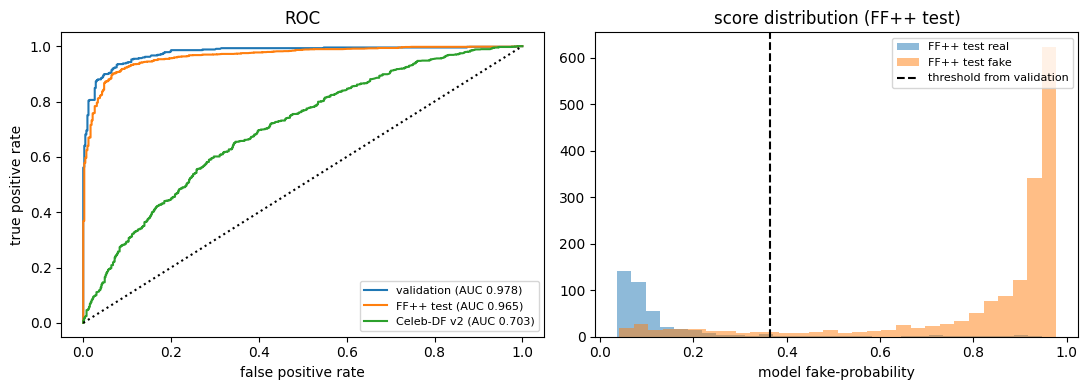

demo images saved to /content/drive/MyDrive/refree/demo_images


In [4]:
# ===== Live evaluation for the evaluator: threshold chosen on VALIDATION, applied unchanged to TEST and Celeb-DF =====
from google.colab import drive; drive.mount('/content/drive')
exec(open('/content/drive/MyDrive/refree/refree_lib.py').read())
assert 'build_model' in globals(), "Drive still has the OLD refree_lib.py"
FACES, DATA = load_all()
model = build_model(); load_best(model)
from sklearn.metrics import confusion_matrix

SETS = (("val", "validation (FF++, used to pick epoch + threshold)"), ("test", "FF++ test (never used for any choice)"), ("unseen", "Celeb-DF v2 (different dataset, zero-shot)"))
score, Y = {}, {}
for s, _ in SETS:
    P, Y[s] = predict(model, DATA[s]); score[s] = P["img"]                       # fake-probability from the image head
fpr, tpr, thr = roc_curve(Y["val"], score["val"]); T = float(thr[np.argmax(tpr - fpr)])   # Youden threshold, from VALIDATION only
print(f"decision threshold chosen on validation: {T:.3f}\n")

rows = []
for s, nm in SETS:
    y, sc = Y[s], score[s]; tn, fp, fn, tp = confusion_matrix(y, sc >= T).ravel(); tpr_, tnr_ = tp / (tp + fn), tn / (tn + fp)
    rows.append(dict(dataset=nm, n=len(y), AUC=roc_auc_score(y, sc), EER=eer_score(y, sc), fake_caught=tpr_, real_kept=tnr_,
                     balanced_acc=(tpr_ + tnr_) / 2, accuracy=(tp + tn) / len(y), TN=tn, FP=fp, FN=fn, TP=tp))
print(pd.DataFrame(rows).round(3).to_string(index=False))

meth = np.array([x["method"] for x in DATA["test"]])
print("\nFF++ test per manipulation method (AUC vs all real faces | share of that method's fakes caught at the threshold):")
for m in sorted(set(meth) - {"real"}):
    sel = (meth == m) | (Y["test"] == 0)
    print(f"  {m:15s} AUC {roc_auc_score(Y['test'][sel], score['test'][sel]):.3f} | caught {np.mean(score['test'][meth == m] >= T):.3f}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for s, nm in SETS:
    f, t, _ = roc_curve(Y[s], score[s]); ax[0].plot(f, t, label=f"{nm.split(' (')[0]} (AUC {roc_auc_score(Y[s], score[s]):.3f})")
    ax[1].hist(score[s][Y[s] == 0], bins=30, alpha=0.5, label=f"{nm.split(' (')[0]} real") if s == "test" else None
ax[0].plot([0, 1], [0, 1], "k:"); ax[0].set_xlabel("false positive rate"); ax[0].set_ylabel("true positive rate"); ax[0].legend(fontsize=8); ax[0].set_title("ROC")
ax[1].hist(score["test"][Y["test"] == 1], bins=30, alpha=0.5, label="FF++ test fake"); ax[1].axvline(T, color="k", ls="--", label="threshold from validation")
ax[1].set_xlabel("model fake-probability"); ax[1].legend(fontsize=8); ax[1].set_title("score distribution (FF++ test)")
plt.tight_layout(); plt.savefig(CK / "live_evaluation.png", dpi=130); plt.show()

# demo images for the upload tool: a FIXED random draw (not cherry-picked), 4 real + 4 fake FF++ test faces, 2 real + 2 fake Celeb-DF faces
from PIL import Image
OUTD = ROOT / "refree" / "demo_images"; OUTD.mkdir(parents=True, exist_ok=True); rr = random.Random(7)
for split, nr, nf in (("test", 4, 4), ("unseen", 2, 2)):
    for lab, k in ((0, nr), (1, nf)):
        for j, i in enumerate(rr.sample([i for i, it in enumerate(DATA[split]) if it["label"] == lab], k)):
            it = DATA[split][i]; Image.fromarray(np.ascontiguousarray(it["img"][..., ::-1])).save(OUTD / f"{split}_{'fake' if lab else 'real'}_{j}.png")
print("demo images saved to", OUTD)

2. Upload an image and get FAKE / REAL with a percentage

This cell restores the model, then offers a web page with an upload box (Gradio, a public link that works while the cell runs). It falls back to a plain Colab upload button if Gradio isn't available. For each image it finds and aligns the largest face the same way as in training, then shows the verdict, the fake and real probability, and the face crop the model actually sees.

In [5]:
# ===== Upload an image -> REAL / FAKE + probability (Colab) =====
from google.colab import drive; drive.mount('/content/drive')
import os, glob, sys, subprocess
PK = "/content/drive/MyDrive/refree/pkgs"
try: import dlib
except ImportError:                                                  # restart-safe: reinstall dlib from the wheel cached on Drive
    tag = f"cp{sys.version_info.major}{sys.version_info.minor}"
    subprocess.run(f"pip install -q {glob.glob(f'{PK}/dlib-*-{tag}-*.whl')[0]}", shell=True, check=True)
if not os.path.exists("/content/shape_predictor_68_face_landmarks.dat"):
    subprocess.run(f"cp {PK}/shape_predictor_68_face_landmarks.dat /content/", shell=True, check=True)
exec(open('/content/drive/MyDrive/refree/refree_lib.py').read())
assert 'build_model' in globals(), "Drive still has the OLD refree_lib.py"
model = build_model()
CKPT = next(p for p in (CK / "final_aug" / "clip3_best.pt", CK / "clip3_best.pt") if p.exists())   # uses the augmented model if you trained one
model.load_state_dict(torch.load(CKPT, map_location=DEVICE)); model.eval(); print("model:", CKPT.parent.name + "/" + CKPT.name)

def analyze(img_bgr, allow_raw=True):
    """detect + align the largest face, score it. Returns (fake_probability, aligned_crop_bgr, note)."""
    lm = detect_landmarks_fast(img_bgr)
    if lm is not None: crop, _ = align_face(img_bgr, lm); note = "face detected and aligned"
    elif allow_raw: crop = cv2.resize(img_bgr, (S, S), interpolation=cv2.INTER_AREA); note = "NO FACE DETECTED - whole image resized instead, result is unreliable"
    else: return None, None, "no face detected"
    P, _ = predict(model, [dict(img=crop, label=0, align_text=REAL_HDR, fusion_text="Heuristic findings: none.")])
    return float(P["img"][0]), crop, note

def verdict(p):
    v = "FAKE" if p >= 0.5 else "REAL"
    flag = "  (borderline - treat as uncertain)" if 0.4 <= p <= 0.6 else ""
    return f"{v}  |  fake probability {100*p:.1f}%  |  real probability {100*(1-p):.1f}%{flag}"

def show(img_bgr, name="image"):
    import matplotlib.pyplot as plt
    p, crop, note = analyze(img_bgr)
    fig, ax = plt.subplots(1, 2, figsize=(7, 3.6)); ax[0].imshow(img_bgr[..., ::-1]); ax[0].set_title(name, fontsize=8); ax[1].imshow(crop[..., ::-1]); ax[1].set_title("face the model sees", fontsize=8)
    for a in ax: a.axis("off")
    fig.suptitle(verdict(p), fontsize=10, color="crimson" if p >= 0.5 else "green"); plt.tight_layout(); plt.show(); print(f"{name}: {verdict(p)} [{note}]")

try:                                                                  # nicer: a web page with an upload box (public link while this cell runs)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gradio"], check=True)
    import gradio as gr
    def gr_fn(img_rgb):
        if img_rgb is None: return {}, None, "upload an image"
        p, crop, note = analyze(np.ascontiguousarray(img_rgb[..., ::-1]))
        return {"FAKE": p, "REAL": 1 - p}, crop[..., ::-1], f"{verdict(p)}\n{note}"
    gr.Interface(fn=gr_fn, inputs=gr.Image(type="numpy", label="upload a face image"),
                 outputs=[gr.Label(num_top_classes=2, label="model output"), gr.Image(label="face the model sees"), gr.Textbox(label="details")],
                 title="Face forgery detector (CLIP ViT-B/16, trained on FaceForensics++ c23)",
                 description="Fake/real probability from the model. Trained on FF++ only: unreliable on other kinds of images.").launch(share=True, debug=False)
except Exception as e:                                                # fallback: plain Colab upload button
    print("Gradio unavailable (", repr(e)[:80], ") -> using the Colab upload button")
    from google.colab import files
    for name, data in files.upload().items():
        img = cv2.imdecode(np.frombuffer(data, np.uint8), cv2.IMREAD_COLOR)
        if img is None: print(name, ": not a readable image"); continue
        show(img, name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
refree_lib loaded | device: cuda


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

ThreeBranchCLIP: 149.9M parameters on cuda
model: refree_ckpt/clip3_best.pt
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d4a03f23f61fa4bc8b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
